# Avance 3: Modelo Baseline — Detección de Brotes de Sarampión
## Proyecto Integrador - Equipo 16

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

Este notebook consolida todos los modelos baseline para la detección de **brotes (picos anómalos)** de sarampión en México utilizando datos mensuales (2010–2023). Se implementan **siete enfoques** de detección de anomalías y se establecen métricas de referencia para evaluar modelos más avanzados en fases posteriores.

**Modelos implementados:**

| # | Método | Tipo | Idea Principal |
|---|--------|------|---------------|
| 1 | **Z-Score** | Estadístico | Un mes es anómalo si sus casos están a >N desviaciones estándar de la media histórica |
| 2 | **Isolation Forest** | ML no supervisado | Los puntos anómalos se aíslan con menos particiones aleatorias en el espacio de features |
| 3 | **Prophet** | Series de Tiempo | Un valor observado fuera del intervalo de incertidumbre del modelo tendencia+estacionalidad es anómalo |
| 4 | **Bayesian Hierarchical** | Bayesiano conjugado | Detección vía p-values de la posterior predictiva Poisson-Gamma |
| 5 | **State Space (UCM)** | Series de Tiempo estructural | Detección vía intervalos de predicción del filtro de Kalman |
| 6 | **Poisson GLM** | Modelo de conteo | GLM con enlace log; predicción de conteos y detección por residuos |
| 7 | **Negative Binomial GLM** | Modelo de conteo | GLM flexible para sobredispersión; detección por residuos |

**Propósito del baseline:**
- Evaluar la **viabilidad del problema**: si el rendimiento es similar al azar, los datos podrían no contener suficiente información predictiva.
- Establecer una **solución mínima aceptable**: incluso un modelo simple puede aportar valor en vigilancia epidemiológica.
- Gestionar **expectativas** sobre lo que se puede lograr antes de invertir en enfoques más complejos.

## 1. Formulación del Problema como Detección de Anomalías

Los brotes de sarampión son eventos **raros y esporádicos**: solo ~10% de los meses en 2010–2023 registraron al menos un caso. Esta distribución extremadamente desbalanceada hace que el enfoque de **detección de anomalías** sea más apropiado que la regresión o clasificación convencional:

- **Normal** = mes sin casos de sarampión (≈90% de las observaciones).
- **Anomalía (brote)** = mes con ≥1 caso confirmado.

Los siete algoritmos de baseline se agrupan en cuatro familias:

| Familia | Métodos | Enfoque |
|---------|---------|---------|
| **Estadístico** | Z-Score (global + rolling) | Desviación respecto a media/σ histórica |
| **ML No Supervisado** | Isolation Forest | Aislamiento en espacio de features multivariado |
| **Series de Tiempo** | Prophet, State Space (UCM) | Intervalos de predicción sobre tendencia + estacionalidad |
| **Bayesiano / Conteo** | Bayesian Hierarchical, Poisson GLM, Negative Binomial GLM | Distribuciones posteriores / residuos de modelos de conteo |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from scipy.stats import nbinom as nbinom_dist
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc, fbeta_score,
)
from prophet import Prophet
from statsmodels.tsa.statespace.structural import UnobservedComponents
import statsmodels.api as sm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# ---------- Carga de datos ----------
base_path = Path("..") / "data" / "processed"

# Dataset original (168 registros mensuales, 4 columnas base)
df_raw = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_raw["fecha"] = pd.to_datetime(
    df_raw["anio"].astype(str) + "-" + df_raw["mes"].astype(str) + "-01"
)
df_raw = df_raw.sort_values("fecha").reset_index(drop=True)

# Dataset con ingeniería de características del Avance 2 (154 registros, 31 columnas)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Variable objetivo binaria: brote = 1 si hay ≥1 caso
df_raw["brote"] = (df_raw["casos_sarampion"] > 0).astype(int)
df_fe["brote"]  = (df_fe["casos_sarampion"] > 0).astype(int)

print(f"Dataset original:    {df_raw.shape[0]} meses ({df_raw['fecha'].min().date()} → {df_raw['fecha'].max().date()})")
print(f"Dataset engineered:  {df_fe.shape[0]} meses ({df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()})")
print(f"\nMeses con brote (original):    {df_raw['brote'].sum()} / {len(df_raw)} ({df_raw['brote'].mean():.1%})")
print(f"Meses con brote (engineered):  {df_fe['brote'].sum()} / {len(df_fe)} ({df_fe['brote'].mean():.1%})")
print(f"\nAños con al menos un brote: {sorted(df_raw.loc[df_raw['brote']==1, 'anio'].unique())}")
display(df_raw.describe())

Dataset original:    168 meses (2010-01-01 → 2023-12-01)
Dataset engineered:  154 meses (2011-03-01 → 2023-12-01)

Meses con brote (original):    17 / 168 (10.1%)
Meses con brote (engineered):  13 / 154 (8.4%)

Años con al menos un brote: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]


,mes,anio,total_dosis,casos_sarampion,fecha,brote
count,168.000000,168.00000,1.680000e+02,168.000000,168,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905,2016-12-15 16:17:08.571428608,0.101190
min,1.000000,2010.00000,1.115500e+04,0.000000,2010-01-01 00:00:00,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000,2013-06-23 12:00:00,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000,2016-12-16 12:00:00,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000,2020-06-08 12:00:00,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000,2023-12-01 00:00:00,1.000000
std,3.462373,4.04318,3.567464e+05,11.132968,NaN,0.302482


## 2. Definición de Métricas

En vigilancia epidemiológica, **no detectar un brote** (falso negativo) tiene consecuencias mucho más graves que una **falsa alarma** (falso positivo):

| Tipo de Error | Consecuencia | Gravedad |
|---------------|-------------|----------|
| **Falso Negativo** (brote no detectado) | Propagación comunitaria sin intervención oportuna; riesgo de epidemia | 🔴 Crítica |
| **Falso Positivo** (falsa alarma) | Investigación epidemiológica innecesaria; costo operativo menor | 🟡 Moderada |

Por tanto, la jerarquía de métricas es:

| Métrica | Prioridad | Justificación |
|---------|-----------|---------------|
| **Recall** | 🔴 Alta | Proporción de brotes reales detectados |
| **F2-Score** | 🔴 Alta | Pondera Recall 2× más que Precision |
| **Precision** | 🟡 Media | Proporción de alertas que son brotes reales |
| **F1-Score** | 🟡 Media | Balance armónico entre Precision y Recall |
| **AUC-PR** | 🟡 Media | Robusta ante desbalance extremo de clases |

> **Métrica principal:** F2-Score (pondera Recall sobre Precision).
> **Métrica secundaria:** Recall — debe ser > 0 para que el modelo tenga utilidad.

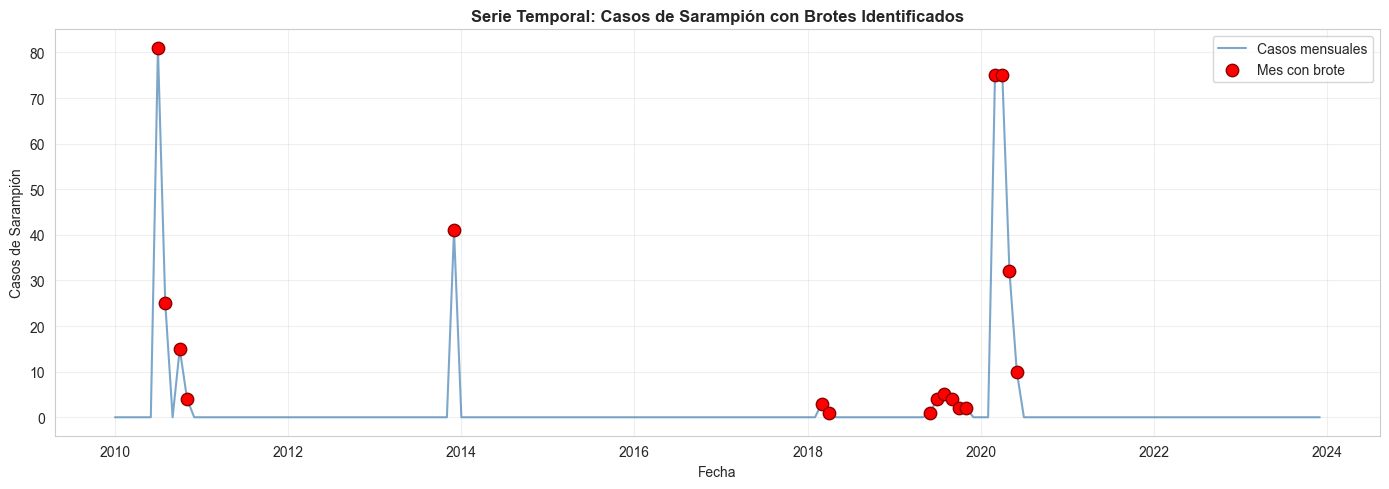


Clase 0 (sin brote): 151 meses
Clase 1 (brote):     17 meses
Ratio de desbalance: 8:1


In [3]:
# ---------- Función de evaluación unificada ----------

def evaluar_detector(y_true, y_pred, nombre, y_score=None):
    """Evalúa un detector de anomalías con métricas epidemiológicas."""
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    auc_pr = np.nan
    if y_score is not None and y_true.sum() > 0:
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
        auc_pr = auc(rec_c, prec_c)

    result = {
        "Modelo": nombre,
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f1, 3),
        "F2": round(f2, 3),
        "AUC-PR": round(auc_pr, 3) if not np.isnan(auc_pr) else np.nan,
        "Brotes_detectados": int(y_pred[y_true == 1].sum()),
        "Brotes_reales": int(y_true.sum()),
        "Falsas_alarmas": int(y_pred[y_true == 0].sum()),
    }

    print(f"\n{'=' * 55}")
    print(f"  {nombre}")
    print(f"{'=' * 55}")
    print(f"  Precision:         {p:.3f}")
    print(f"  Recall:            {r:.3f}")
    print(f"  F1-Score:          {f1:.3f}")
    print(f"  F2-Score:          {f2:.3f}")
    if not np.isnan(auc_pr):
        print(f"  AUC-PR:            {auc_pr:.3f}")
    print(f"  Brotes detectados: {int(y_pred[y_true == 1].sum())} / {int(y_true.sum())}")
    print(f"  Falsas alarmas:    {int(y_pred[y_true == 0].sum())}")

    return result


# ---------- Visualizar serie temporal con brotes marcados ----------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_raw["fecha"], df_raw["casos_sarampion"],
        color="steelblue", alpha=0.7, label="Casos mensuales")

brotes_mask = df_raw["brote"] == 1
ax.scatter(df_raw.loc[brotes_mask, "fecha"],
           df_raw.loc[brotes_mask, "casos_sarampion"],
           color="red", s=80, zorder=5, label="Mes con brote", edgecolors="darkred")

ax.set_xlabel("Fecha")
ax.set_ylabel("Casos de Sarampión")
ax.set_title("Serie Temporal: Casos de Sarampión con Brotes Identificados", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n0 = (df_raw["brote"] == 0).sum()
n1 = (df_raw["brote"] == 1).sum()
print(f"\nClase 0 (sin brote): {n0} meses")
print(f"Clase 1 (brote):     {n1} meses")
print(f"Ratio de desbalance: {n0 // max(n1, 1)}:1")

## 3. Partición Temporal

Se realiza un split cronológico estricto para respetar la naturaleza temporal de los datos:

- **Entrenamiento (fit):** 2010–2018 — historia previa a los brotes principales.
- **Prueba (score):** 2019–2023 — incluye los brotes significativos de 2019–2020 y el período post-brote, permitiendo evaluar tanto la detección de anomalías reales como la tasa de falsas alarmas.

**Justificación del corte en 2019:**
Los principales brotes de sarampión en México ocurrieron en 2019–2020. Incluirlos en el set de prueba permite evaluar Recall y F2-Score de forma significativa. Un corte posterior (e.g., 2021) dejaría el test sin brotes reales, haciendo imposible medir la sensibilidad del detector.

In [4]:
SPLIT_YEAR = 2019

# --- Split dataset original (para Z-Score, Prophet, Bayesian, State Space) ---
train_raw = df_raw[df_raw["anio"] < SPLIT_YEAR].copy()
test_raw  = df_raw[df_raw["anio"] >= SPLIT_YEAR].copy()

# --- Split dataset engineered (para Isolation Forest, Poisson GLM, NB GLM) ---
train_fe = df_fe[df_fe["anio"] < SPLIT_YEAR].copy()
test_fe  = df_fe[df_fe["anio"] >= SPLIT_YEAR].copy()

# Variable objetivo completa
y_true_full = df_raw["brote"].values

print("Partición temporal")
print(f"{'─' * 60}")
print(f"  Train (original):    {len(train_raw):>4} meses | Brotes: {train_raw['brote'].sum()}")
print(f"  Test  (original):    {len(test_raw):>4} meses | Brotes: {test_raw['brote'].sum()}")
print(f"  Train (engineered):  {len(train_fe):>4} meses | Brotes: {train_fe['brote'].sum()}")
print(f"  Test  (engineered):  {len(test_fe):>4} meses | Brotes: {test_fe['brote'].sum()}")

if test_raw["brote"].sum() == 0:
    print("\nEl set de prueba NO contiene brotes.")
    print("   La evaluación temporal medirá únicamente falsas alarmas.")
    print("   La evaluación principal será retrospectiva (dataset completo).")
else:
    print(f"\n✅ El set de prueba contiene {test_raw['brote'].sum()} meses con brote.")
    print("   Se podrá evaluar Recall y F2-Score en test.")

Partición temporal
────────────────────────────────────────────────────────────
  Train (original):     108 meses | Brotes: 7
  Test  (original):      60 meses | Brotes: 10
  Train (engineered):    94 meses | Brotes: 3
  Test  (engineered):    60 meses | Brotes: 10

✅ El set de prueba contiene 10 meses con brote.
   Se podrá evaluar Recall y F2-Score en test.


In [5]:
# Lista para acumular resultados de todos los modelos
all_results = []

## 4. Baseline 1: Detección por Z-Score

### Fundamento

El Z-Score mide cuántas desviaciones estándar se aleja una observación de la media

**Variantes implementadas:**
1. **Z-Score global:** usa $\mu$ y $\sigma$ de toda la serie de entrenamiento.
2. **Z-Score rolling:** usa una ventana móvil de 12 meses previos, capturando cambios en la dinámica local.

In [6]:
# ============================================================
# 4. BASELINE 1 — Z-Score
# ============================================================

# --- Z-Score Global (estadísticos de entrenamiento) ---
mu_train    = train_raw["casos_sarampion"].mean()
sigma_train = train_raw["casos_sarampion"].std()

df_raw["zscore_global"] = (df_raw["casos_sarampion"] - mu_train) / sigma_train

# --- Z-Score Rolling (ventana 12 meses, solo datos pasados) ---
ROLLING_WINDOW = 12
r_mean = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).mean()
r_std  = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).std()
r_std  = r_std.replace(0, np.nan)  # evitar div/0

df_raw["zscore_rolling"] = (df_raw["casos_sarampion"] - r_mean) / r_std

print("Estadísticos de entrenamiento (Z-Score Global):")
print(f"  μ = {mu_train:.3f} casos/mes")
print(f"  σ = {sigma_train:.3f}")
print(f"  Umbral z>1 ≈ {mu_train + 1*sigma_train:.1f} casos")
print(f"  Umbral z>2 ≈ {mu_train + 2*sigma_train:.1f} casos")
print(f"  Umbral z>3 ≈ {mu_train + 3*sigma_train:.1f} casos")

# --- Barrido de umbrales ---
thresholds_z = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
rows_z = []
for t in thresholds_z:
    yp = (df_raw["zscore_global"] > t).astype(int).values
    rows_z.append({
        "Umbral z": t,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_z = pd.DataFrame(rows_z)
print("\nBarrido de umbrales — Z-Score Global (evaluación retrospectiva):")
display(df_thresh_z)

best_idx = df_thresh_z["F2"].idxmax()
BEST_Z   = df_thresh_z.loc[best_idx, "Umbral z"]
print(f"\n★ Mejor umbral por F2: z > {BEST_Z}")

Estadísticos de entrenamiento (Z-Score Global):
  μ = 1.574 casos/mes
  σ = 9.095
  Umbral z>1 ≈ 10.7 casos
  Umbral z>2 ≈ 19.8 casos
  Umbral z>3 ≈ 28.9 casos

Barrido de umbrales — Z-Score Global (evaluación retrospectiva):


,Umbral z,Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.00,1.0,0.882,0.938,0.904,15,0
1,0.25,1.0,0.706,0.828,0.750,12,0
2,0.50,1.0,0.471,0.640,0.526,8,0
3,1.00,1.0,0.412,0.583,0.467,7,0
4,1.50,1.0,0.353,0.522,0.405,6,0
5,2.00,1.0,0.353,0.522,0.405,6,0
6,2.50,1.0,0.353,0.522,0.405,6,0
7,3.00,1.0,0.294,0.455,0.342,5,0



★ Mejor umbral por F2: z > 0.0



  Z-Score Global (z > 0.0)
  Precision:         1.000
  Recall:            0.882
  F1-Score:          0.938
  F2-Score:          0.904
  AUC-PR:            1.000
  Brotes detectados: 15 / 17
  Falsas alarmas:    0

  Z-Score Rolling 12m (z > 0.0)
  Precision:         1.000
  Recall:            0.846
  F1-Score:          0.917
  F2-Score:          0.873
  AUC-PR:            0.958
  Brotes detectados: 11 / 13
  Falsas alarmas:    0


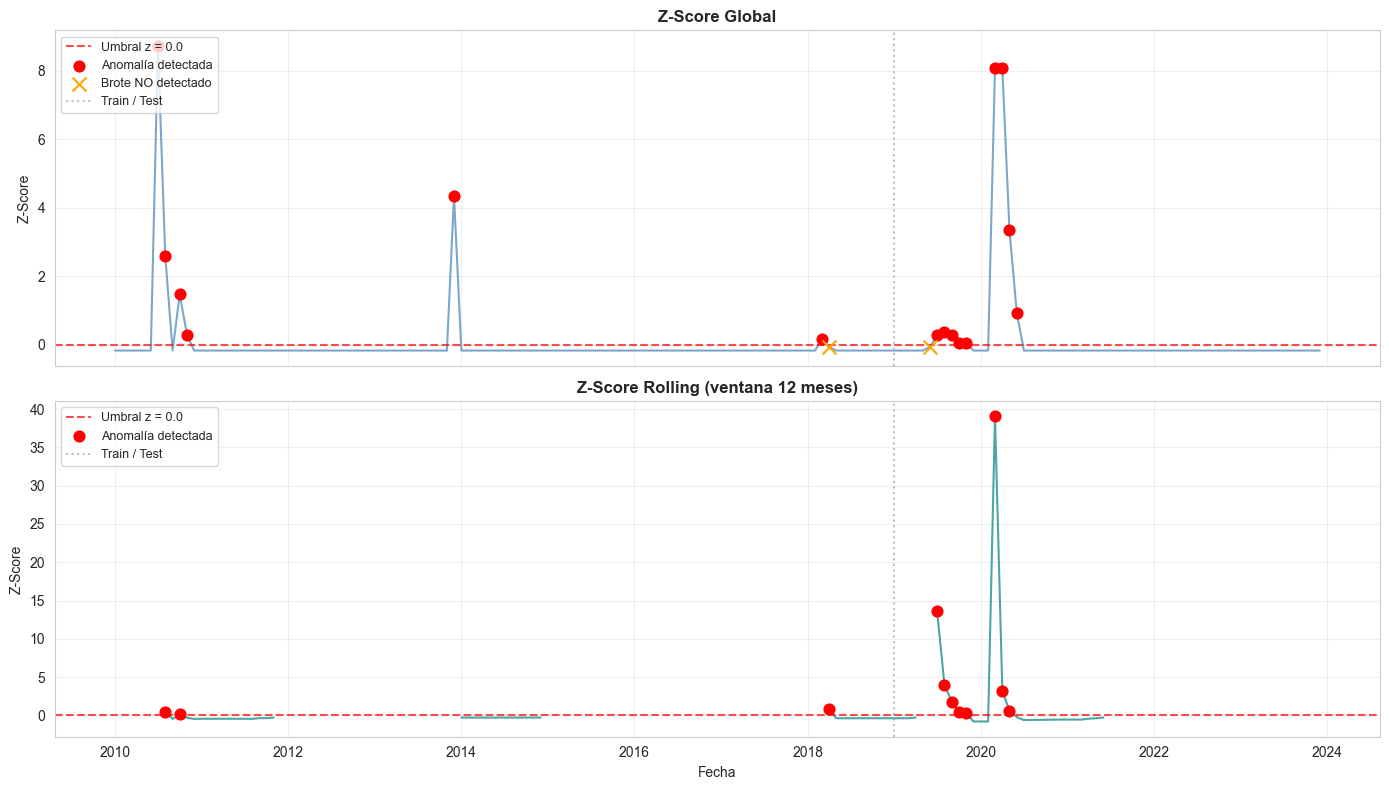

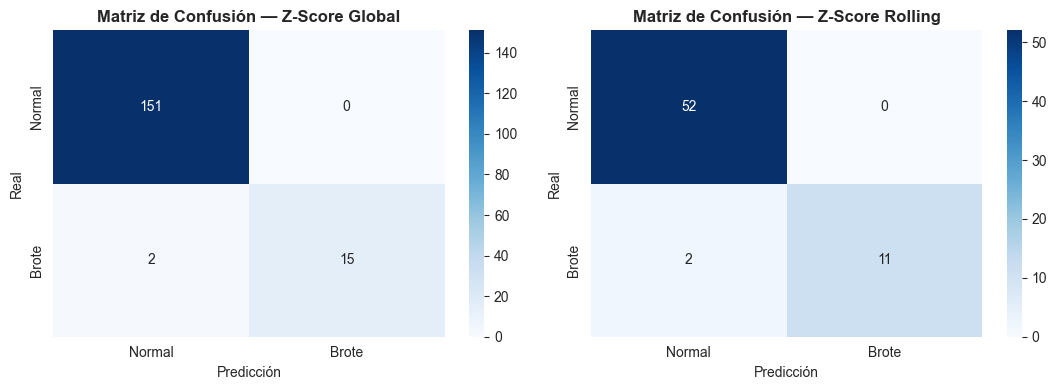

In [7]:
# --- Evaluación Z-Score Global con mejor umbral ---
y_pred_zg  = (df_raw["zscore_global"] > BEST_Z).astype(int).values
score_zg   = df_raw["zscore_global"].values
res_zg     = evaluar_detector(y_true_full, y_pred_zg,
                              f"Z-Score Global (z > {BEST_Z})",
                              y_score=score_zg)
all_results.append(res_zg)

# --- Evaluación Z-Score Rolling (solo filas válidas) ---
valid_mask  = ~df_raw["zscore_rolling"].isna()
y_true_v    = df_raw.loc[valid_mask, "brote"].values
y_pred_zr   = (df_raw.loc[valid_mask, "zscore_rolling"] > BEST_Z).astype(int).values
score_zr    = df_raw.loc[valid_mask, "zscore_rolling"].values
res_zr      = evaluar_detector(y_true_v, y_pred_zr,
                               f"Z-Score Rolling 12m (z > {BEST_Z})",
                               y_score=score_zr)
all_results.append(res_zr)

# ---- Visualización ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Z-Score Global
axes[0].plot(df_raw["fecha"], df_raw["zscore_global"], color="steelblue", alpha=0.7)
axes[0].axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_g = df_raw.index[y_pred_zg == 1]
axes[0].scatter(df_raw.loc[det_g, "fecha"], df_raw.loc[det_g, "zscore_global"],
                color="red", s=60, zorder=5, label="Anomalía detectada")
missed_g = df_raw.index[(df_raw["brote"] == 1) & (y_pred_zg == 0)]
if len(missed_g):
    axes[0].scatter(df_raw.loc[missed_g, "fecha"], df_raw.loc[missed_g, "zscore_global"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Z-Score")
axes[0].set_title("Z-Score Global", fontweight="bold")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Z-Score Rolling
axes[1].plot(df_raw["fecha"], df_raw["zscore_rolling"], color="teal", alpha=0.7)
axes[1].axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_r = df_raw.index[(df_raw["zscore_rolling"] > BEST_Z).fillna(False)]
if len(det_r):
    axes[1].scatter(df_raw.loc[det_r, "fecha"], df_raw.loc[det_r, "zscore_rolling"],
                    color="red", s=60, zorder=5, label="Anomalía detectada")
axes[1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Z-Score Rolling (ventana 12 meses)", fontweight="bold")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Matrices de confusión ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yp, yt, title in [
    (axes[0], y_pred_zg, y_true_full, "Z-Score Global"),
    (axes[1], y_pred_zr, y_true_v,    "Z-Score Rolling"),
]:
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusión — {title}", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Baseline 2: Isolation Forest

### Fundamento

Isolation Forest aísla observaciones mediante particiones aleatorias recursivas del espacio de características. Las anomalías, al ser escasas y diferentes, requieren **menos particiones** para ser aisladas, lo que se traduce en **caminos más cortos** en los árboles → mayor probabilidad de anomalía.

**Ventajas para este problema:**
- **Multivariado**: utiliza las 12+ características seleccionadas en el Avance 2 (vacunación, temporalidad, lags, tendencias).
- **No supervisado**: no requiere etiquetas de brote para el entrenamiento.
- **Robusto** ante distribuciones no normales y outliers.

**Hiperparámetros clave:**
- `contamination`: proporción esperada de anomalías, fijada en la proporción observada de brotes en el set de entrenamiento.
- `n_estimators`: número de árboles de aislamiento (200).

Features utilizadas: 27
Contamination rate:  0.032

Features:
['casos_sarampion_log', 'casos_ytd_log', 'casos_rolling_mean_3m', 'dosis_lag_14m_log', 'dosis_lag_13m_log', 'casos_rolling_mean_6m_log', 'dosis_rolling_mean_3m_log', 'total_dosis_log', 'dosis_rolling_std_3m_log', 'casos_lag_13m_log', 'anio_normalizado', 'dosis_rolling_std_6m_log', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']

  Isolation Forest (retrospectivo)
  Precision:         0.429
  Recall:            0.692
  F1-Score:          0.529
  F2-Score:          0.616
  AUC-PR:            0.658
  Brotes detectados: 9 / 13
  Falsas alarmas:    12

  Isolation Forest (test)
  Precision:         0.444
  Recall:            0.800
  F1-Score:          0.571
  F2-Score:          0.690
  AUC-PR:            0.787
  Brotes detectados: 8 / 10
  Falsas alarmas:    10


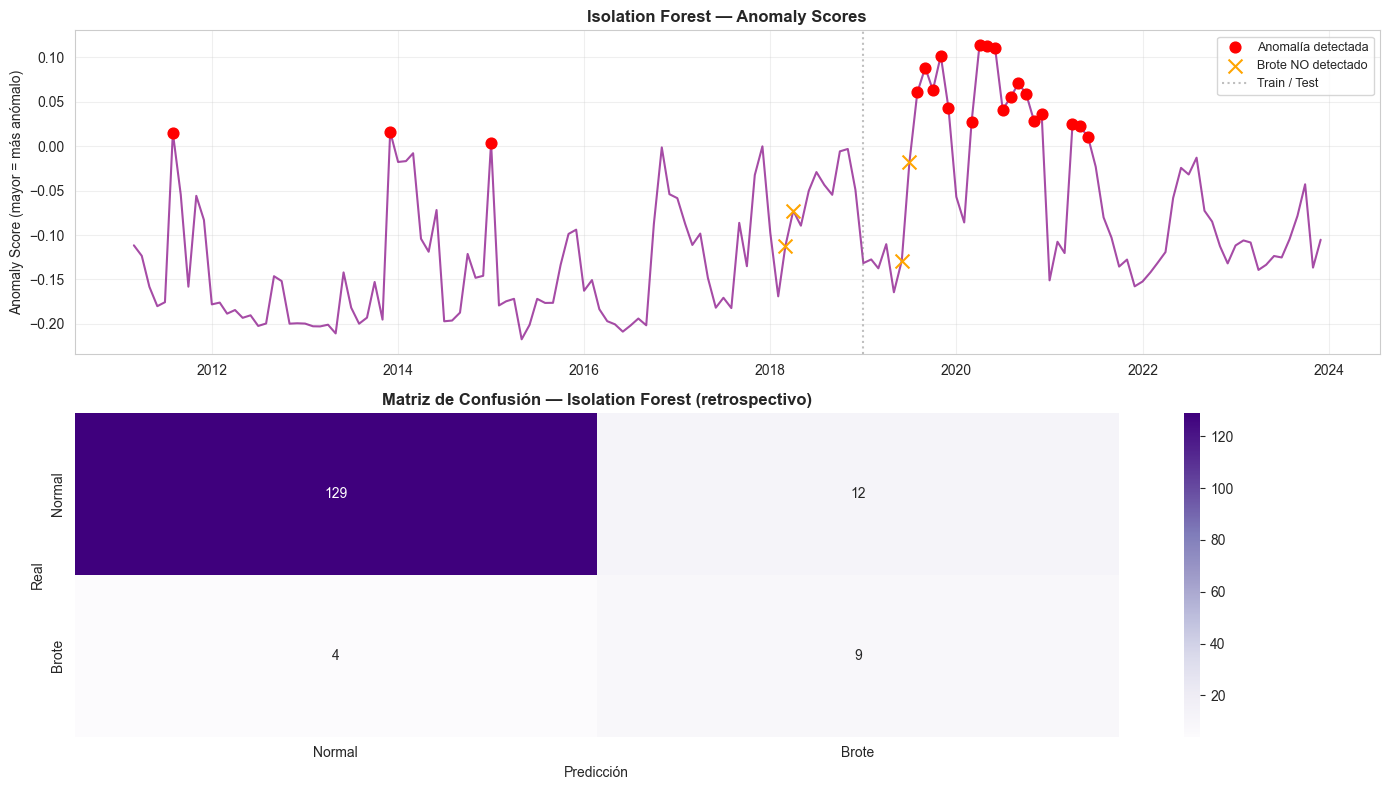

In [8]:
# ============================================================
# 5. BASELINE 2 — Isolation Forest
# ============================================================

# --- Selección de features (excluir identificadores y target) ---
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"}
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

X_train_if = train_fe[feature_cols].values
X_test_if  = test_fe[feature_cols].values
X_full_if  = df_fe[feature_cols].values

y_train_if = train_fe["brote"].values
y_test_if  = test_fe["brote"].values
y_full_if  = df_fe["brote"].values

# Contamination = proporción observada de brotes en train
contamination_rate = max(y_train_if.mean(), 0.01)

print(f"Features utilizadas: {len(feature_cols)}")
print(f"Contamination rate:  {contamination_rate:.3f}")
print(f"\nFeatures:\n{feature_cols}")

# --- Entrenar Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_if)

# --- Predicciones ---
scores_full_if = iso_forest.decision_function(X_full_if)
scores_test_if = iso_forest.decision_function(X_test_if)

preds_full = iso_forest.predict(X_full_if)
y_pred_if_full = np.where(preds_full == -1, 1, 0)

preds_test = iso_forest.predict(X_test_if)
y_pred_if_test = np.where(preds_test == -1, 1, 0)

# --- Evaluación retrospectiva (dataset completo engineered) ---
res_if = evaluar_detector(y_full_if, y_pred_if_full,
                          "Isolation Forest (retrospectivo)",
                          y_score=-scores_full_if)
all_results.append(res_if)

# --- Evaluación temporal (test set) ---
if y_test_if.sum() > 0:
    res_if_test = evaluar_detector(y_test_if, y_pred_if_test,
                                   "Isolation Forest (test)",
                                   y_score=-scores_test_if)
else:
    fa_test = int(y_pred_if_test.sum())
    print(f"\n  Isolation Forest (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_test}")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: Anomaly Scores
axes[0].plot(df_fe["fecha"], -scores_full_if, color="purple", alpha=0.7)
det_if_idx = np.where(y_pred_if_full == 1)[0]
axes[0].scatter(df_fe.iloc[det_if_idx]["fecha"], -scores_full_if[det_if_idx],
                color="red", s=60, zorder=5, label="Anomalía detectada")
brote_if_idx = np.where(y_full_if == 1)[0]
missed_if = [i for i in brote_if_idx if y_pred_if_full[i] == 0]
if missed_if:
    axes[0].scatter(df_fe.iloc[missed_if]["fecha"], -scores_full_if[missed_if],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Anomaly Score (mayor = más anómalo)")
axes[0].set_title("Isolation Forest — Anomaly Scores", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_if = confusion_matrix(y_full_if, y_pred_if_full)
sns.heatmap(cm_if, annot=True, fmt="d", cmap="Purples", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Isolation Forest (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.1 Importancia de Características — Isolation Forest

¿Se puede determinar la importancia de las características? Sí: se usa **importancia por permutación**, que mide cuánto empeora el F2-Score al aleatorizar cada feature. Las features cuya permutación causa mayor pérdida de rendimiento son las más relevantes para el detector.

F2 base del modelo: 0.616

Importancia por permutación (ΔF2):


,Feature,ΔF2 (importancia)
0,casos_sarampion_log,0.126828
1,PCA_6,0.107248
2,PCA_3,0.063906
3,PCA_7,0.045643
4,anio_normalizado,0.016385
5,FA_4,0.011935
6,total_dosis_log,0.011157
7,FA_1,0.008658
8,casos_rolling_mean_6m_log,0.007735
9,casos_ytd_log,0.007309


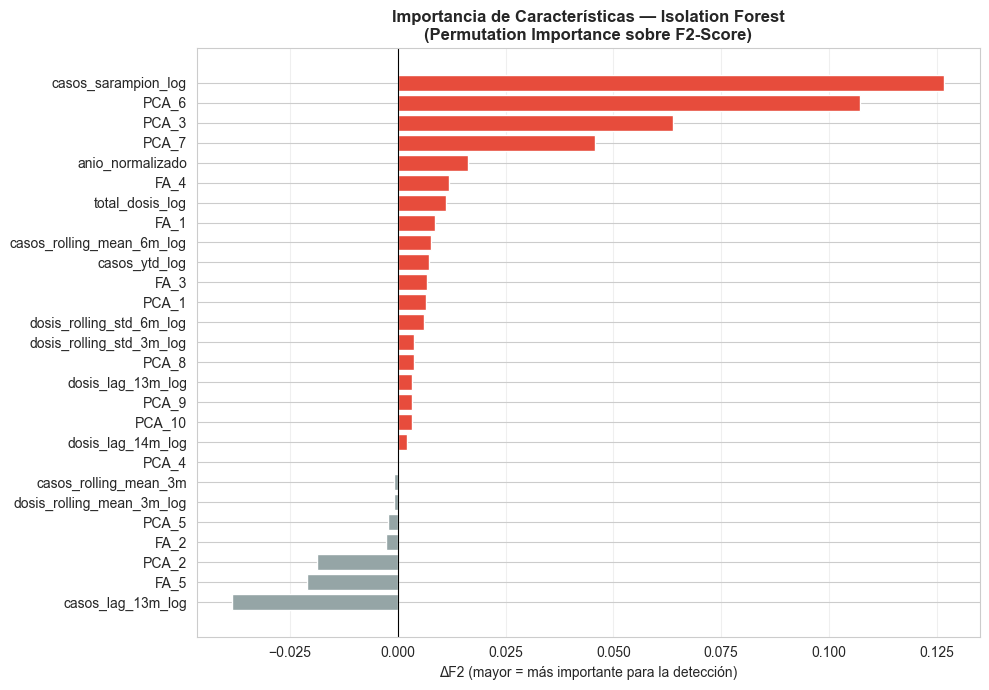


Features con importancia positiva significativa: 19
  → ['casos_sarampion_log', 'PCA_6', 'PCA_3', 'PCA_7', 'anio_normalizado', 'FA_4', 'total_dosis_log', 'FA_1', 'casos_rolling_mean_6m_log', 'casos_ytd_log', 'FA_3', 'PCA_1', 'dosis_rolling_std_6m_log', 'dosis_rolling_std_3m_log', 'PCA_8', 'dosis_lag_13m_log', 'PCA_9', 'PCA_10', 'dosis_lag_14m_log']

Características irrelevantes (ΔF2 ≈ 0 o negativa) podrían eliminarse
para reducir complejidad sin sacrificar rendimiento.


In [9]:
# ============================================================
# 5.1 IMPORTANCIA DE CARACTERÍSTICAS (Permutation Importance)
# ============================================================

np.random.seed(42)
base_f2 = fbeta_score(y_full_if, y_pred_if_full, beta=2, zero_division=0)

N_REPEATS = 20
importances = {}

for col_idx, col_name in enumerate(feature_cols):
    deltas = []
    for _ in range(N_REPEATS):
        X_perm = X_full_if.copy()
        X_perm[:, col_idx] = np.random.permutation(X_perm[:, col_idx])
        preds_perm = iso_forest.predict(X_perm)
        y_perm = np.where(preds_perm == -1, 1, 0)
        f2_perm = fbeta_score(y_full_if, y_perm, beta=2, zero_division=0)
        deltas.append(base_f2 - f2_perm)
    importances[col_name] = np.mean(deltas)

imp_df = (pd.Series(importances)
          .sort_values(ascending=False)
          .reset_index()
          .rename(columns={"index": "Feature", 0: "ΔF2 (importancia)"}))

print(f"F2 base del modelo: {base_f2:.3f}\n")
print("Importancia por permutación (ΔF2):")
display(imp_df)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E74C3C" if v > 0.001 else "#3498DB" if v > 0 else "#95A5A6"
          for v in imp_df["ΔF2 (importancia)"]]
ax.barh(imp_df["Feature"][::-1], imp_df["ΔF2 (importancia)"][::-1], color=colors[::-1])
ax.set_xlabel("ΔF2 (mayor = más importante para la detección)")
ax.set_title("Importancia de Características — Isolation Forest\n(Permutation Importance sobre F2-Score)",
             fontweight="bold")
ax.axvline(0, color="black", lw=0.8)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Resumen
top_feats = imp_df[imp_df["ΔF2 (importancia)"] > 0.001]["Feature"].tolist()
print(f"\nFeatures con importancia positiva significativa: {len(top_feats)}")
if top_feats:
    print(f"  → {top_feats}")
print("\nCaracterísticas irrelevantes (ΔF2 ≈ 0 o negativa) podrían eliminarse")
print("para reducir complejidad sin sacrificar rendimiento.")

## 6. Baseline 3: Prophet

### Fundamento

Prophet es un modelo de series de tiempo desarrollado por Meta.

El uso de Prophet es ideal para este problema porque está diseñado específicamente para superar los retos de los datos epidemiológicos del mundo real. A diferencia de modelos tradicionales, Prophet es muy robusto ante datos faltantes o valores atípicos (como retrasos o errores en los reportes de salud) y modela con gran precisión múltiples estacionalidades, lo cual es perfecto para capturar los ciclos naturales del sarampión. Además, detecta automáticamente cambios drásticos en la tendencia, permitiendo evaluar exactamente cómo las caídas o aumentos en las tasas de vacunación alteran la curva de contagios.

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018) y se pronostica todo el período.
- `interval_width=0.95` (intervalo de confianza al 95%).
- `changepoint_prior_scale=0.05` (conservador, evita sobreajuste a fluctuaciones locales).

23:24:56 - cmdstanpy - INFO - Chain [1] start processing
23:24:56 - cmdstanpy - INFO - Chain [1] done processing



  Prophet (retrospectivo)
  Precision:         1.000
  Recall:            0.353
  F1-Score:          0.522
  F2-Score:          0.405
  AUC-PR:            0.718
  Brotes detectados: 6 / 17
  Falsas alarmas:    0

  Prophet (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


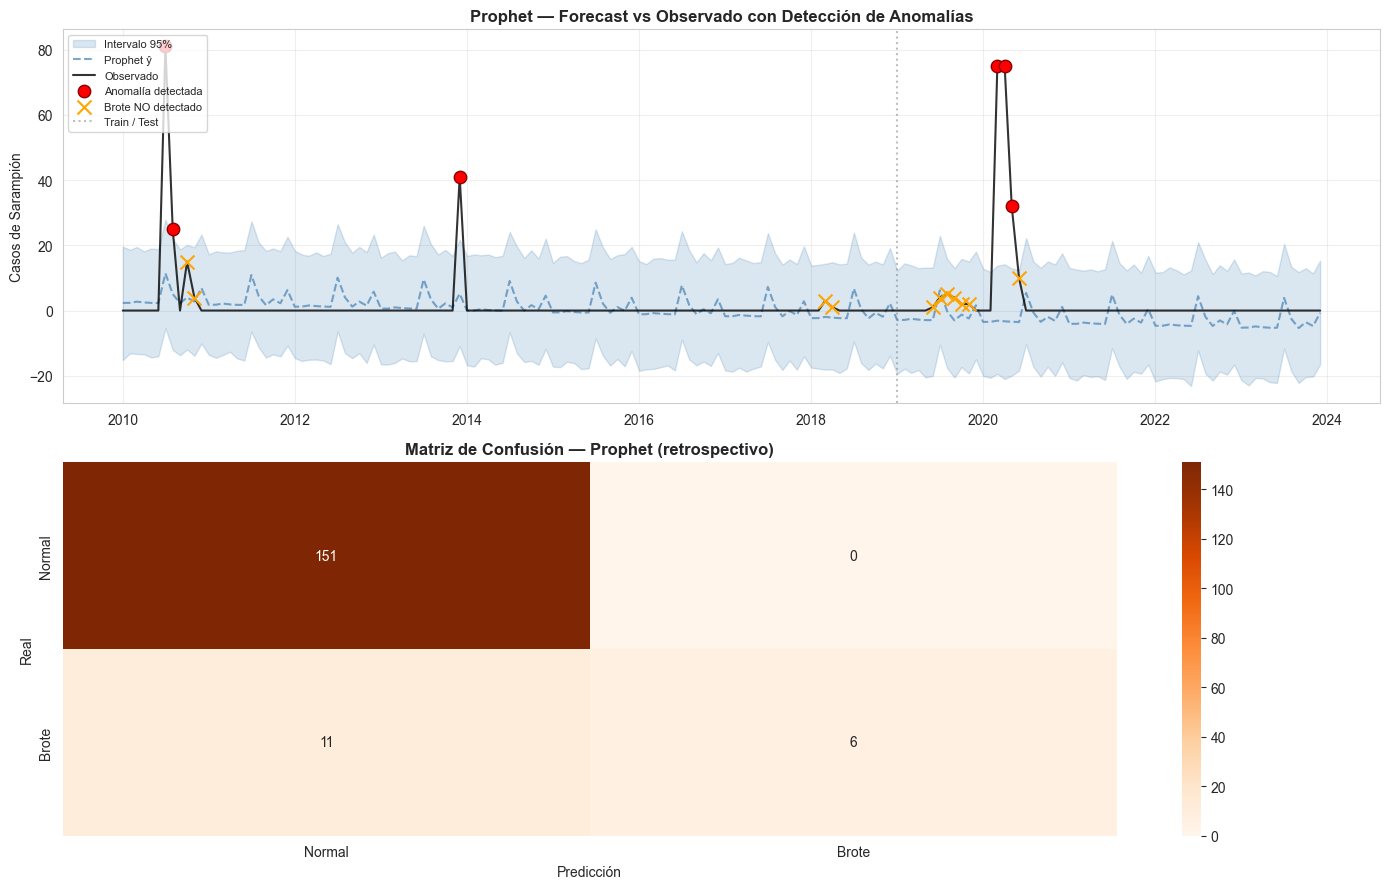

In [10]:
# ============================================================
# 6. BASELINE 3 — Prophet
# ============================================================

# Preparar datos para Prophet (requiere columnas 'ds' y 'y')
df_prophet_train = pd.DataFrame({
    "ds": train_raw["fecha"],
    "y":  train_raw["casos_sarampion"],
})

# Ajustar modelo
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
)
prophet_model.fit(df_prophet_train)

# Predecir para todo el período
future = pd.DataFrame({"ds": df_raw["fecha"]})
forecast = prophet_model.predict(future)

# Detectar anomalías: observado > yhat_upper
df_raw["prophet_yhat"]    = forecast["yhat"].values
df_raw["prophet_upper"]   = forecast["yhat_upper"].values
df_raw["prophet_lower"]   = forecast["yhat_lower"].values
df_raw["prophet_anomaly"] = (df_raw["casos_sarampion"] > forecast["yhat_upper"].values).astype(int)

# --- Evaluación retrospectiva ---
y_pred_prophet = df_raw["prophet_anomaly"].values
prophet_score = df_raw["casos_sarampion"].values - df_raw["prophet_upper"].values

res_prophet = evaluar_detector(y_true_full, y_pred_prophet,
                               "Prophet (retrospectivo)",
                               y_score=prophet_score)
all_results.append(res_prophet)

# --- Evaluación temporal (test set) ---
y_test_prophet = test_raw["brote"].values
y_pred_prophet_test = df_raw.loc[df_raw["anio"] >= SPLIT_YEAR, "prophet_anomaly"].values
if y_test_prophet.sum() > 0:
    evaluar_detector(y_test_prophet, y_pred_prophet_test, "Prophet (test)")
else:
    fa_prophet_test = int(y_pred_prophet_test.sum())
    print(f"\n  Prophet (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_prophet_test}")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Serie + forecast + anomalías
axes[0].fill_between(df_raw["fecha"], df_raw["prophet_lower"], df_raw["prophet_upper"],
                     alpha=0.2, color="steelblue", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], df_raw["prophet_yhat"], color="steelblue",
             ls="--", alpha=0.7, label="Prophet ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")
anom_mask = df_raw["prophet_anomaly"] == 1
axes[0].scatter(df_raw.loc[anom_mask, "fecha"], df_raw.loc[anom_mask, "casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
missed_p = (df_raw["brote"] == 1) & (df_raw["prophet_anomaly"] == 0)
if missed_p.any():
    axes[0].scatter(df_raw.loc[missed_p, "fecha"], df_raw.loc[missed_p, "casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("Prophet — Forecast vs Observado con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_p = confusion_matrix(y_true_full, y_pred_prophet)
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Prophet (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Baseline 4: Modelo Bayesiano Jerárquico (Poisson-Gamma)

### Fundamento

El modelo Bayesiano jerárquico combina información previa con los datos observados para estimar la distribución de la tasa de casos por mes. Utiliza el framework conjugado **Poisson-Gamma**

Su enfoque bayesiano permite incorporar conocimiento epidemiológico previo (como la altísima contagiosidad histórica del sarampión) y entrega resultados en forma de probabilidades; esto significa que el modelo no solo predice una tendencia, sino que indica la probabilidad exacta y el riesgo estadístico de que detone un brote basado en caracteristicas como la cobertura de vacunación

In [11]:
# ============================================================
# 7. BASELINE 4 — Bayesian Hierarchical Model (Poisson-Gamma)
# ============================================================

# --- Hiperparámetros globales (Empirical Bayes via método de momentos) ---
global_mean_train = train_raw["casos_sarampion"].mean()
global_var_train  = train_raw["casos_sarampion"].var()

if global_var_train > global_mean_train and global_mean_train > 0:
    beta_0  = global_mean_train / max(global_var_train, 1e-6)
    alpha_0 = global_mean_train * beta_0
else:
    alpha_0, beta_0 = 0.5, 0.5  # prior débilmente informativo

print("Hiperparámetros del prior Gamma(α₀, β₀):")
print(f"  α₀ = {alpha_0:.4f}")
print(f"  β₀ = {beta_0:.4f}")
print(f"  E[λ] prior = {alpha_0 / beta_0:.3f}")

# --- Posterior por mes (actualización conjugada) ---
posteriors_by_month = {}
print(f"\nPosterior por mes (Gamma actualizada con datos de entrenamiento):")
print(f"{'Mes':>4} | {'n_obs':>5} | {'Σy':>5} | {'α_post':>8} | {'β_post':>8} | {'E[λ]_post':>10}")
print("─" * 60)

for mes in range(1, 13):
    month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
    n_m    = len(month_data)
    sum_ym = int(month_data.sum())

    alpha_post = alpha_0 + sum_ym
    beta_post  = beta_0 + n_m

    posteriors_by_month[mes] = (alpha_post, beta_post)
    print(f"{mes:>4} | {n_m:>5} | {sum_ym:>5} | {alpha_post:>8.3f} | {beta_post:>8.3f} | {alpha_post / beta_post:>10.3f}")

Hiperparámetros del prior Gamma(α₀, β₀):
  α₀ = 0.0300
  β₀ = 0.0190
  E[λ] prior = 1.574

Posterior por mes (Gamma actualizada con datos de entrenamiento):
 Mes | n_obs |    Σy |   α_post |   β_post |  E[λ]_post
────────────────────────────────────────────────────────────
   1 |     9 |     0 |    0.030 |    9.019 |      0.003
   2 |     9 |     0 |    0.030 |    9.019 |      0.003
   3 |     9 |     3 |    3.030 |    9.019 |      0.336
   4 |     9 |     1 |    1.030 |    9.019 |      0.114
   5 |     9 |     0 |    0.030 |    9.019 |      0.003
   6 |     9 |     0 |    0.030 |    9.019 |      0.003
   7 |     9 |    81 |   81.030 |    9.019 |      8.984
   8 |     9 |    25 |   25.030 |    9.019 |      2.775
   9 |     9 |     0 |    0.030 |    9.019 |      0.003
  10 |     9 |    15 |   15.030 |    9.019 |      1.666
  11 |     9 |     4 |    4.030 |    9.019 |      0.447
  12 |     9 |    41 |   41.030 |    9.019 |      4.549


In [12]:
# --- Detección de anomalías via posterior predictive ---
BAYES_ALPHA = 0.05

y_pred_bayes  = np.zeros(len(df_raw), dtype=int)
bayes_pvalues = np.zeros(len(df_raw))

for idx in range(len(df_raw)):
    mes   = int(df_raw.iloc[idx]["mes"])
    y_obs = int(df_raw.iloc[idx]["casos_sarampion"])
    alpha_post, beta_post = posteriors_by_month[mes]

    r = alpha_post
    p = beta_post / (1.0 + beta_post)

    if y_obs > 0:
        p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
    else:
        p_value = 1.0

    bayes_pvalues[idx] = p_value
    y_pred_bayes[idx]  = 1 if p_value < BAYES_ALPHA else 0

bayes_scores = 1.0 - bayes_pvalues

# --- Evaluación retrospectiva ---
res_bayes = evaluar_detector(y_true_full, y_pred_bayes,
                             f"Bayesian Hierarchical (α={BAYES_ALPHA})",
                             y_score=bayes_scores)
all_results.append(res_bayes)

# --- Evaluación temporal (test set) ---
test_mask_bayes = df_raw["anio"] >= SPLIT_YEAR
y_test_bayes = df_raw.loc[test_mask_bayes, "brote"].values
y_pred_bayes_test = y_pred_bayes[test_mask_bayes.values]

if y_test_bayes.sum() > 0:
    bayes_scores_test = bayes_scores[test_mask_bayes.values]
    evaluar_detector(y_test_bayes, y_pred_bayes_test,
                     "Bayesian Hierarchical (test)", y_score=bayes_scores_test)
else:
    fa_bayes_test = int(y_pred_bayes_test.sum())
    print(f"\n  Bayesian (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_bayes_test}")


  Bayesian Hierarchical (α=0.05)
  Precision:         1.000
  Recall:            0.706
  F1-Score:          0.828
  F2-Score:          0.750
  AUC-PR:            1.000
  Brotes detectados: 12 / 17
  Falsas alarmas:    0

  Bayesian Hierarchical (test)
  Precision:         1.000
  Recall:            0.600
  F1-Score:          0.750
  F2-Score:          0.652
  AUC-PR:            1.000
  Brotes detectados: 6 / 10
  Falsas alarmas:    0


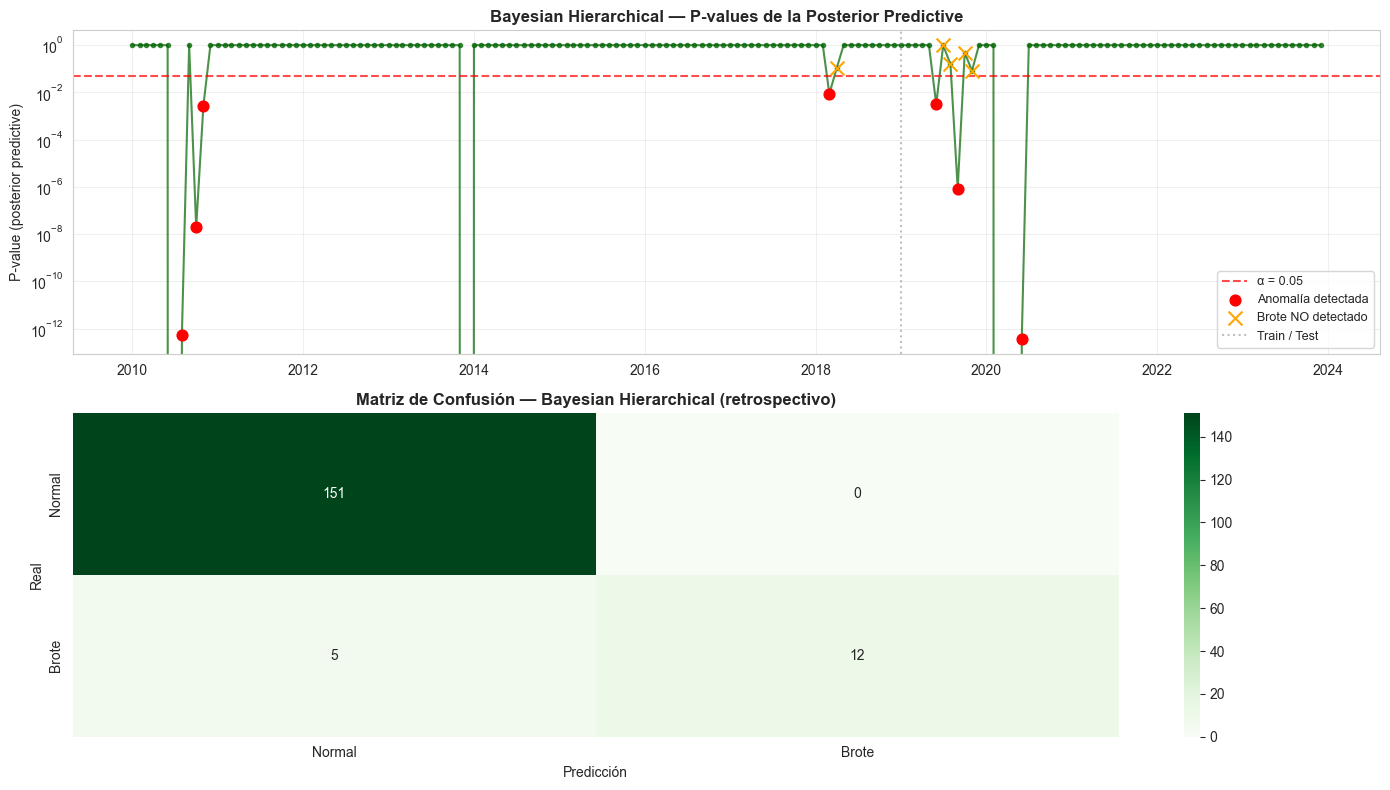


Barrido de umbrales α — Bayesian Hierarchical (evaluación retrospectiva):


,α (significancia),Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.010,1.0,0.706,0.828,0.750,12,0
1,0.025,1.0,0.706,0.828,0.750,12,0
2,0.050,1.0,0.706,0.828,0.750,12,0
3,0.100,1.0,0.765,0.867,0.802,13,0
4,0.150,1.0,0.824,0.903,0.854,14,0
5,0.200,1.0,0.882,0.938,0.904,15,0
6,0.300,1.0,0.882,0.938,0.904,15,0


In [13]:
# --- Visualización Bayesian ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: P-values con umbral
axes[0].plot(df_raw["fecha"], bayes_pvalues, color="darkgreen", alpha=0.7, marker="o", ms=3)
axes[0].axhline(BAYES_ALPHA, color="red", ls="--", alpha=0.7, label=f"α = {BAYES_ALPHA}")

det_bayes_idx = np.where(y_pred_bayes == 1)[0]
axes[0].scatter(df_raw.iloc[det_bayes_idx]["fecha"], bayes_pvalues[det_bayes_idx],
                color="red", s=60, zorder=5, label="Anomalía detectada")
brote_idx = np.where(y_true_full == 1)[0]
missed_bayes = [i for i in brote_idx if y_pred_bayes[i] == 0]
if missed_bayes:
    axes[0].scatter(df_raw.iloc[missed_bayes]["fecha"], bayes_pvalues[missed_bayes],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("P-value (posterior predictive)")
axes[0].set_title("Bayesian Hierarchical — P-values de la Posterior Predictive", fontweight="bold")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_bayes = confusion_matrix(y_true_full, y_pred_bayes)
sns.heatmap(cm_bayes, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Bayesian Hierarchical (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

# --- Barrido de umbrales α ---
alphas_sweep = [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30]
rows_bayes = []
for a in alphas_sweep:
    yp = (bayes_pvalues < a).astype(int)
    rows_bayes.append({
        "α (significancia)": a,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_bayes = pd.DataFrame(rows_bayes)
print("\nBarrido de umbrales α — Bayesian Hierarchical (evaluación retrospectiva):")
display(df_thresh_bayes)

## 8. Baseline 5: Modelo de Espacio de Estados (State Space)

### Fundamento

El modelo de **Componentes No Observados** (Unobserved Components Model, UCM) descompone la serie temporal en componentes estructurales latentes.

**Detección de anomalías con State Space:**
El modelo genera intervalos de predicción. Un mes es **anómalo** si el valor observado excede el límite superior del intervalo de confianza al 95%

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018).
- Nivel local + estacionalidad estocástica de 12 meses.
- Implementación via `statsmodels.tsa.statespace.structural.UnobservedComponents`.

In [14]:
# ============================================================
# 8. BASELINE 5 — State Space Model (Unobserved Components)
# ============================================================

# --- Preparar serie temporal con frecuencia mensual ---
train_series_ss = (train_raw
                   .set_index("fecha")["casos_sarampion"]
                   .asfreq("MS")
                   .fillna(0))

print(f"Serie de entrenamiento: {len(train_series_ss)} meses")
print(f"  Rango: {train_series_ss.index.min().date()} → {train_series_ss.index.max().date()}")

# --- Ajustar modelo de componentes no observados ---
uc_model = UnobservedComponents(
    train_series_ss,
    level="local level",
    seasonal=12,
    stochastic_seasonal=True,
)
uc_result = uc_model.fit(disp=False, maxiter=500)

print(f"\nModelo ajustado:")
print(f"  Log-Likelihood: {uc_result.llf:.2f}")
print(f"  AIC: {uc_result.aic:.2f}")
print(f"  BIC: {uc_result.bic:.2f}")

# --- Predicciones in-sample (train) ---
in_sample_pred = uc_result.get_prediction(start=0, end=len(train_series_ss) - 1)
in_sample_ci   = in_sample_pred.conf_int(alpha=0.05)

# --- Predicciones out-of-sample (test) ---
n_test_ss = len(test_raw)
oos_pred = uc_result.get_forecast(steps=n_test_ss)
oos_ci   = oos_pred.conf_int(alpha=0.05)

# --- Combinar predicciones para todo el período ---
upper_train_ss = in_sample_ci.iloc[:, 1].values
upper_test_ss  = oos_ci.iloc[:, 1].values
upper_full_ss  = np.concatenate([upper_train_ss, upper_test_ss])

yhat_train_ss = in_sample_pred.predicted_mean.values
yhat_test_ss  = oos_pred.predicted_mean.values
yhat_full_ss  = np.concatenate([yhat_train_ss, yhat_test_ss])

lower_train_ss = in_sample_ci.iloc[:, 0].values
lower_test_ss  = oos_ci.iloc[:, 0].values
lower_full_ss  = np.concatenate([lower_train_ss, lower_test_ss])

print(f"\nPredicciones generadas: {len(upper_full_ss)} meses (train: {len(upper_train_ss)}, test: {len(upper_test_ss)})")

Serie de entrenamiento: 108 meses
  Rango: 2010-01-01 → 2018-12-01

Modelo ajustado:
  Log-Likelihood: -360.97
  AIC: 727.95
  BIC: 735.64

Predicciones generadas: 168 meses (train: 108, test: 60)


In [15]:
# --- Detección de anomalías: observado > límite superior ---
y_obs_ss = df_raw["casos_sarampion"].values
y_pred_ss = (y_obs_ss > upper_full_ss).astype(int)

# Score: residuo normalizado (mayor = más anómalo)
residuals_ss = y_obs_ss - yhat_full_ss
ss_range = np.maximum(upper_full_ss - yhat_full_ss, 1e-6)
ss_scores = residuals_ss / ss_range

# --- Evaluación retrospectiva ---
res_ss = evaluar_detector(y_true_full, y_pred_ss,
                          "State Space (retrospectivo)",
                          y_score=ss_scores)
all_results.append(res_ss)

# --- Evaluación temporal (test set) ---
test_mask_ss = df_raw["anio"] >= SPLIT_YEAR
y_test_ss_vals = df_raw.loc[test_mask_ss, "brote"].values
y_pred_ss_test = y_pred_ss[test_mask_ss.values]

if y_test_ss_vals.sum() > 0:
    ss_scores_test = ss_scores[test_mask_ss.values]
    evaluar_detector(y_test_ss_vals, y_pred_ss_test,
                     "State Space (test)", y_score=ss_scores_test)
else:
    fa_ss_test = int(y_pred_ss_test.sum())
    print(f"\n  State Space (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_ss_test}")


  State Space (retrospectivo)
  Precision:         1.000
  Recall:            0.235
  F1-Score:          0.381
  F2-Score:          0.278
  AUC-PR:            0.630
  Brotes detectados: 4 / 17
  Falsas alarmas:    0

  State Space (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  AUC-PR:            0.854
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


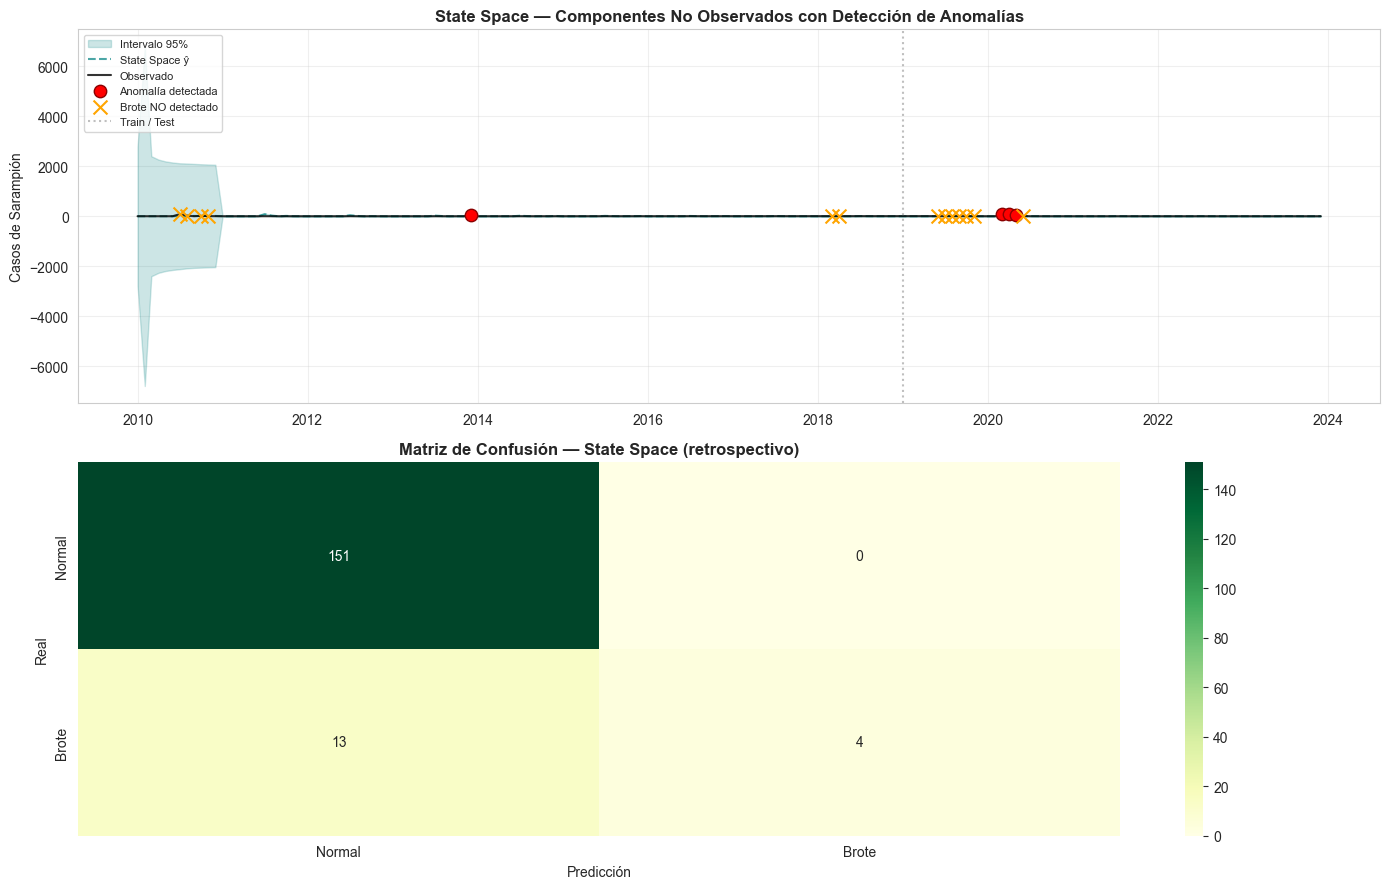

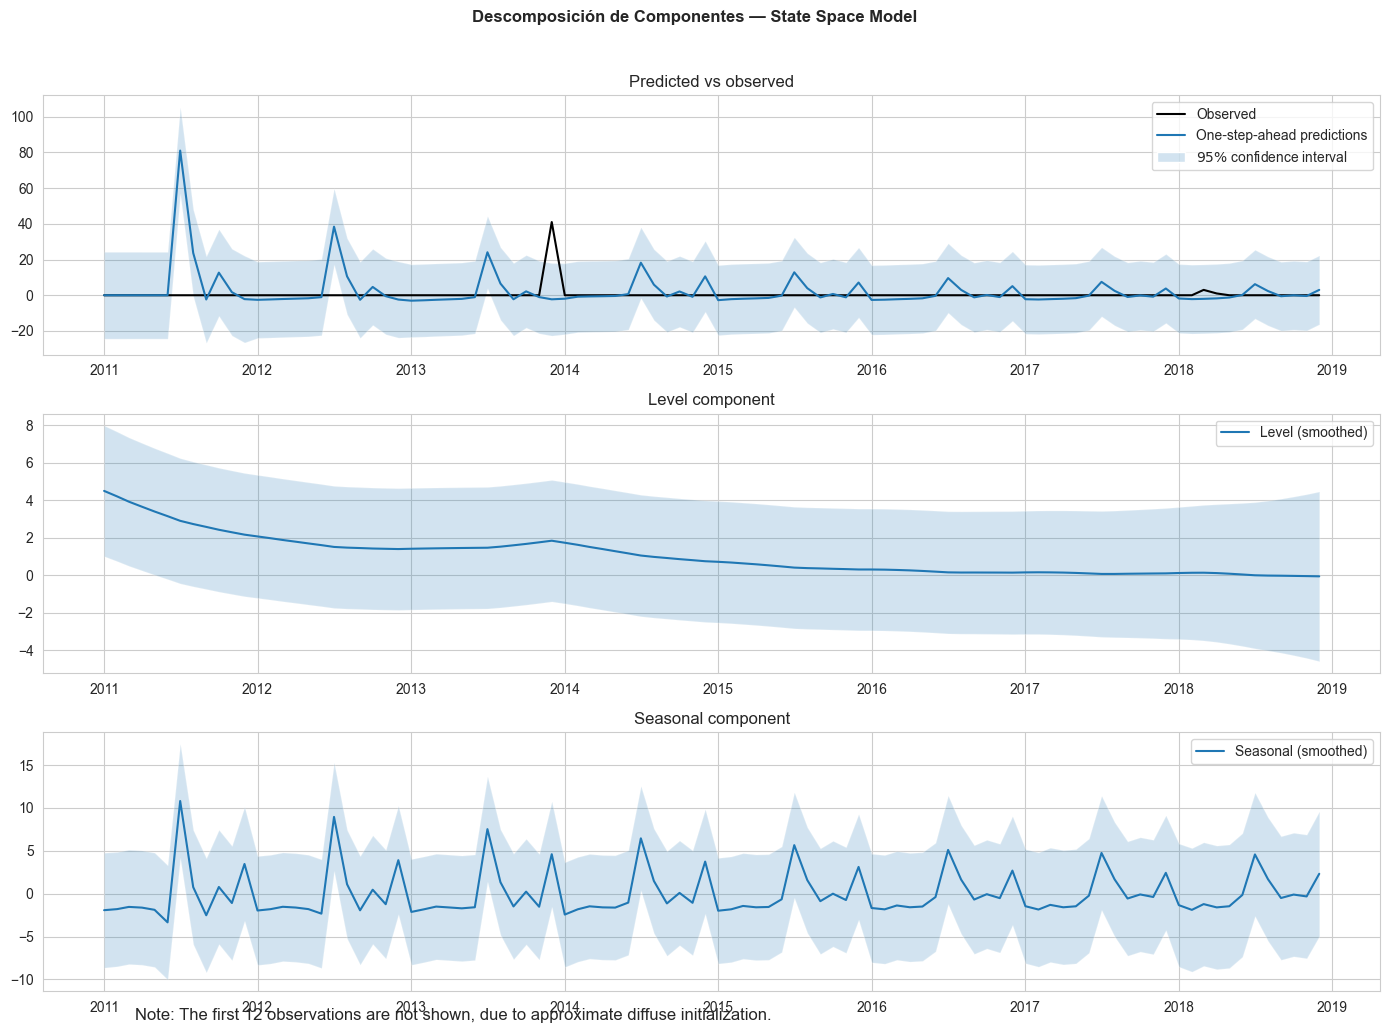

In [16]:
# --- Visualización State Space ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Serie + State Space predictions + anomalías
axes[0].fill_between(df_raw["fecha"], lower_full_ss, upper_full_ss,
                     alpha=0.2, color="teal", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], yhat_full_ss, color="teal",
             ls="--", alpha=0.7, label="State Space ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")

det_ss_idx = np.where(y_pred_ss == 1)[0]
axes[0].scatter(df_raw.iloc[det_ss_idx]["fecha"],
                df_raw.iloc[det_ss_idx]["casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
brote_ss_idx = np.where(y_true_full == 1)[0]
missed_ss = [i for i in brote_ss_idx if y_pred_ss[i] == 0]
if missed_ss:
    axes[0].scatter(df_raw.iloc[missed_ss]["fecha"],
                    df_raw.iloc[missed_ss]["casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("State Space — Componentes No Observados con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_ss = confusion_matrix(y_true_full, y_pred_ss)
sns.heatmap(cm_ss, annot=True, fmt="d", cmap="YlGn", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — State Space (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

# --- Descomposición de componentes ---
fig = uc_result.plot_components(figsize=(14, 10))
plt.suptitle("Descomposición de Componentes — State Space Model", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Baselines 6 y 7: Modelos de Conteo — Poisson GLM y Negative Binomial GLM

### Fundamento

Los modelos lineales generalizados (GLM) para datos de conteo son una alternativa natural para modelar el número de casos de sarampión.

Se quiere predecir  un numero de casos por mes. Ese numero es un conteo (0, 1, 2, ...) y no una variable continua. Por eso evaluaremos el rendimiento de  modelos de conteo.

- **Poisson**: es el modelo base para conteos. Supone que la variabilidad es similar al promedio. Funciona bien cuando los datos no tienen demasiados ceros extra ni picos extremos.
- **Negative Binomial**: es una version mas flexible. Mantiene el enlace log, pero permite mas variabilidad que el promedio. En series con brotes y muchos ceros, suele ajustarse mejor.

Adicionalmente se reportan métricas de conteo nativas (MAE, RMSE, Poisson Deviance) para contexto.

In [17]:
# ============================================================
# 9. BASELINES 6 & 7 — Poisson GLM y Negative Binomial GLM
# ============================================================

# --- Preparar dataset con lag features ---
df_glm = df_fe.copy()
target = "casos_sarampion"

# Retardos del target para capturar dependencia temporal
df_glm["casos_lag_1m"]  = df_glm[target].shift(1)
df_glm["casos_lag_12m"] = df_glm[target].shift(12)

# --- Partición temporal con SPLIT_YEAR ---
train_glm = df_glm[df_glm["anio"] < SPLIT_YEAR].copy()
test_glm  = df_glm[df_glm["anio"] >= SPLIT_YEAR].copy()
# Para evaluación retrospectiva, usamos todo el dataset
full_glm = df_glm.copy()

# Selección de covariables: todas las numéricas excepto identificadores y target
glm_exclude = {"anio", "mes", "fecha", target, "brote"}
num_cols = df_glm.select_dtypes(include=[np.number]).columns.tolist()
glm_feature_cols = [c for c in num_cols if c not in glm_exclude]

# Asegurar que los lags estén incluidos
for lag_col in ["casos_lag_1m", "casos_lag_12m"]:
    if lag_col not in glm_feature_cols:
        glm_feature_cols.append(lag_col)

# Armado de matrices de diseño
train_x_glm = sm.add_constant(train_glm[glm_feature_cols].fillna(0), has_constant="add")
test_x_glm  = sm.add_constant(test_glm[glm_feature_cols].fillna(0), has_constant="add")
full_x_glm  = sm.add_constant(full_glm[glm_feature_cols].fillna(0), has_constant="add")

train_y_glm = train_glm[target].copy()
test_y_glm  = test_glm[target].copy()
full_y_glm  = full_glm[target].copy()

print(f"Features GLM: {len(glm_feature_cols)}")
print(f"Train: {len(train_glm)} meses | Test: {len(test_glm)} meses")
print(f"Brotes train: {(train_glm['brote']==1).sum()} | Brotes test: {(test_glm['brote']==1).sum()}")

Features GLM: 29
Train: 94 meses | Test: 60 meses
Brotes train: 3 | Brotes test: 10


In [18]:
# --- Ajuste Poisson GLM ---
poisson_model = sm.GLM(train_y_glm, train_x_glm, family=sm.families.Poisson()).fit()

# --- Ajuste Negative Binomial GLM (búsqueda de alpha por AIC) ---
alpha_grid = [0.1, 0.3, 0.5, 1.0, 2.0]
nb_models = []
for a in alpha_grid:
    nb = sm.GLM(train_y_glm, train_x_glm, family=sm.families.NegativeBinomial(alpha=a)).fit()
    nb_models.append((a, nb.aic, nb))
best_alpha, best_aic, nb_model = sorted(nb_models, key=lambda x: x[1])[0]

print(f"Mejor alpha NB por AIC: {best_alpha} | AIC: {best_aic:.2f}")

# Sobredispersión en Poisson
poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Dispersión Poisson (pearson_chi2/df_resid): {poisson_dispersion:.2f}")
print(f"  → {'Sobredispersión detectada' if poisson_dispersion > 1 else 'Sin sobredispersión significativa'}")

print(f"\nPoisson AIC: {poisson_model.aic:.2f}")
print(f"NegBin  AIC: {nb_model.aic:.2f}")

# --- Métricas de conteo nativas ---
def poisson_deviance(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 1e-9, None)
    term = np.where(y_true == 0, -y_pred, y_true * np.log(y_true / y_pred) - (y_true - y_pred))
    return 2 * np.mean(term)

def eval_count_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "Poisson_Deviance": poisson_deviance(y_true, y_pred),
    }

# Predicciones en test
pred_pois_test = poisson_model.predict(test_x_glm)
pred_nb_test   = nb_model.predict(test_x_glm)

print("\n--- Métricas de conteo (test set) ---")
print(f"Poisson:  {eval_count_metrics(test_y_glm, pred_pois_test)}")
print(f"NegBin:   {eval_count_metrics(test_y_glm, pred_nb_test)}")

Mejor alpha NB por AIC: 0.1 | AIC: 42.55
Dispersión Poisson (pearson_chi2/df_resid): 0.00
  → Sin sobredispersión significativa

Poisson AIC: 40.55
NegBin  AIC: 42.55

--- Métricas de conteo (test set) ---
Poisson:  {'MAE': np.float64(2.093136393924163e+28), 'RMSE': np.float64(1.621336478999913e+29), 'Poisson_Deviance': np.float64(4.186272787848324e+28)}
NegBin:   {'MAE': np.float64(1.992566869765082e+44), 'RMSE': np.float64(1.5434356602119112e+45), 'Poisson_Deviance': np.float64(-3.985133739529914e+44)}


In [19]:
# ============================================================
# 9.1 Detección de anomalías via residuos estandarizados
# ============================================================

# Predicciones retrospectivas (dataset completo engineered)
pred_pois_full = poisson_model.predict(full_x_glm)
pred_nb_full   = nb_model.predict(full_x_glm)

# --- Poisson GLM: residuos de Pearson ---
# Var(Y) = μ para Poisson
resid_pois = (full_y_glm.values - pred_pois_full) / np.sqrt(np.maximum(pred_pois_full, 1e-9))
# Anomalía: residuo > 2
GLM_RESID_THRESHOLD = 2.0
y_pred_pois = (resid_pois > GLM_RESID_THRESHOLD).astype(int)

# Score para AUC-PR: residuo estandarizado (mayor = más anómalo)
y_full_glm = full_glm["brote"].values

res_pois = evaluar_detector(y_full_glm, y_pred_pois,
                            f"Poisson GLM (residuo > {GLM_RESID_THRESHOLD})",
                            y_score=resid_pois)
all_results.append(res_pois)

# --- Negative Binomial GLM: residuos de Pearson ---
# Var(Y) = μ + α*μ² para NB
nb_var = pred_nb_full + best_alpha * pred_nb_full**2
resid_nb = (full_y_glm.values - pred_nb_full) / np.sqrt(np.maximum(nb_var, 1e-9))
y_pred_nb = (resid_nb > GLM_RESID_THRESHOLD).astype(int)

res_nb = evaluar_detector(y_full_glm, y_pred_nb,
                          f"NegBin GLM (residuo > {GLM_RESID_THRESHOLD})",
                          y_score=resid_nb)
all_results.append(res_nb)

# --- Evaluación temporal (test set) ---
test_mask_glm = full_glm["anio"] >= SPLIT_YEAR
y_test_glm_vals = full_glm.loc[test_mask_glm, "brote"].values

y_pred_pois_test = y_pred_pois[test_mask_glm.values]
y_pred_nb_test   = y_pred_nb[test_mask_glm.values]

if y_test_glm_vals.sum() > 0:
    evaluar_detector(y_test_glm_vals, y_pred_pois_test, "Poisson GLM (test)")
    evaluar_detector(y_test_glm_vals, y_pred_nb_test, "NegBin GLM (test)")
else:
    print(f"\n  Poisson GLM (test): Falsas alarmas = {int(y_pred_pois_test.sum())}")
    print(f"  NegBin GLM (test):  Falsas alarmas = {int(y_pred_nb_test.sum())}")


  Poisson GLM (residuo > 2.0)
  Precision:         1.000
  Recall:            0.154
  F1-Score:          0.267
  F2-Score:          0.185
  AUC-PR:            0.503
  Brotes detectados: 2 / 13
  Falsas alarmas:    0

  NegBin GLM (residuo > 2.0)
  Precision:         1.000
  Recall:            0.308
  F1-Score:          0.471
  F2-Score:          0.357
  AUC-PR:            0.434
  Brotes detectados: 4 / 13
  Falsas alarmas:    0

  Poisson GLM (test)
  Precision:         1.000
  Recall:            0.200
  F1-Score:          0.333
  F2-Score:          0.238
  Brotes detectados: 2 / 10
  Falsas alarmas:    0

  NegBin GLM (test)
  Precision:         1.000
  Recall:            0.400
  F1-Score:          0.571
  F2-Score:          0.455
  Brotes detectados: 4 / 10
  Falsas alarmas:    0


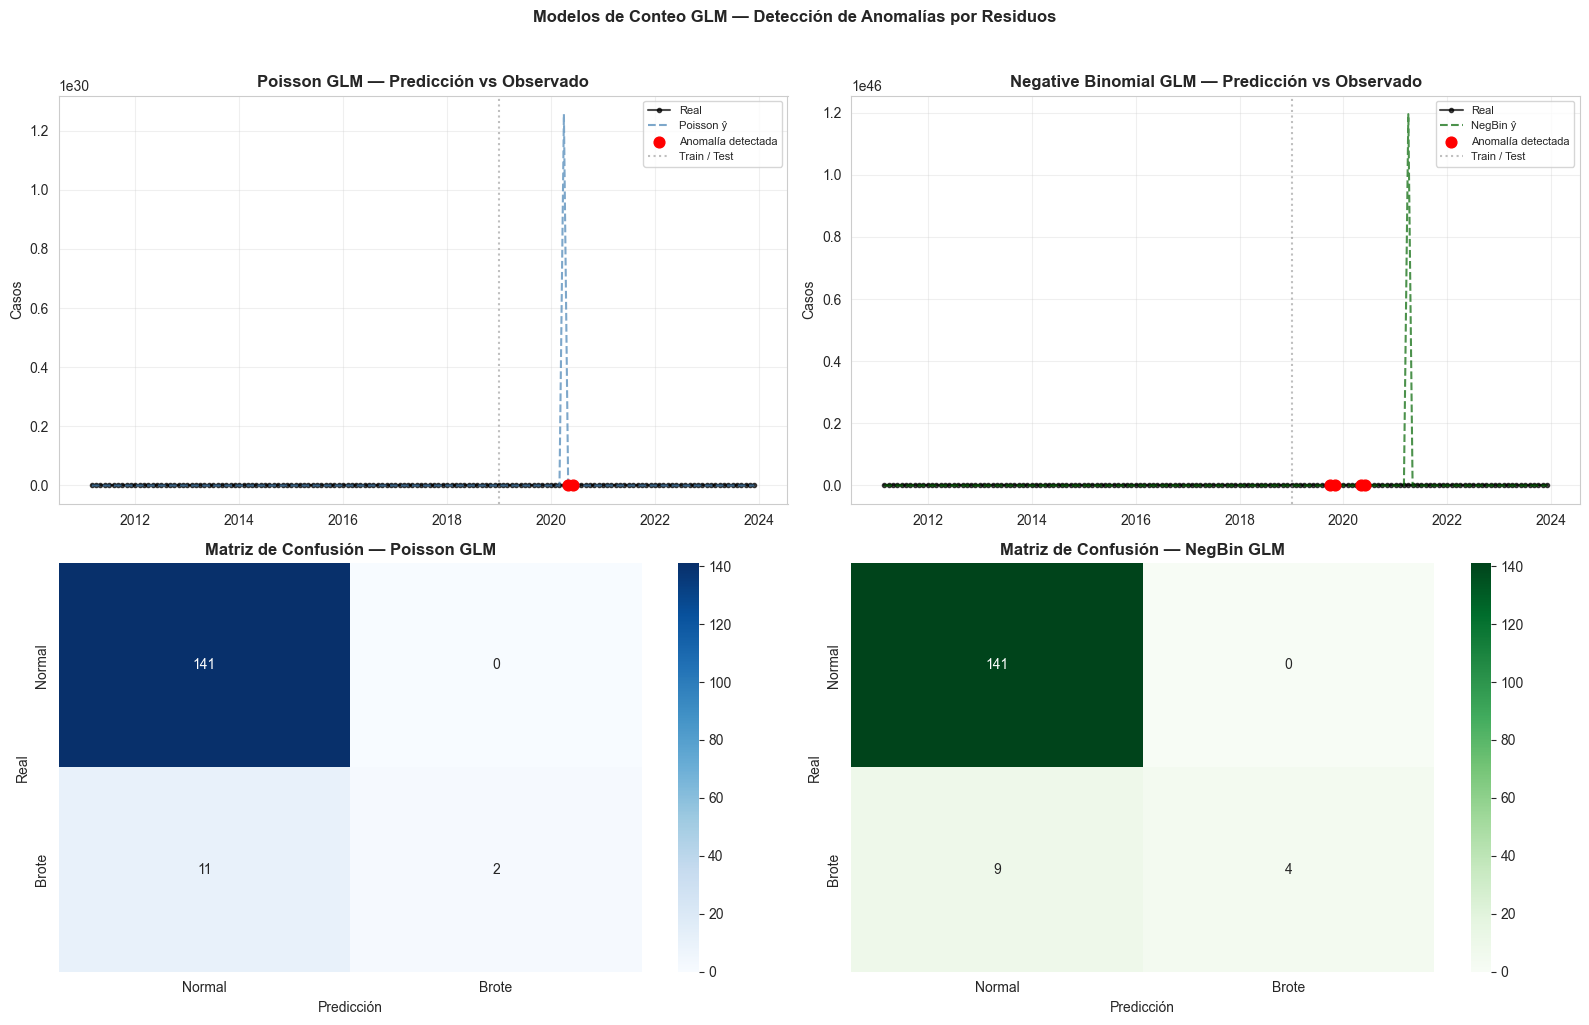

In [20]:
# --- Visualización GLM ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Poisson - Predicciones vs Observado
axes[0, 0].plot(full_glm["fecha"], full_y_glm, label="Real", marker="o", ms=3, color="black", alpha=0.7)
axes[0, 0].plot(full_glm["fecha"], pred_pois_full, label="Poisson ŷ", ls="--", color="steelblue", alpha=0.7)
det_pois_idx = np.where(y_pred_pois == 1)[0]
if len(det_pois_idx):
    axes[0, 0].scatter(full_glm.iloc[det_pois_idx]["fecha"], full_y_glm.values[det_pois_idx],
                        color="red", s=60, zorder=5, label="Anomalía detectada")
axes[0, 0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0, 0].set_title("Poisson GLM — Predicción vs Observado", fontweight="bold")
axes[0, 0].set_ylabel("Casos")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: NB - Predicciones vs Observado
axes[0, 1].plot(full_glm["fecha"], full_y_glm, label="Real", marker="o", ms=3, color="black", alpha=0.7)
axes[0, 1].plot(full_glm["fecha"], pred_nb_full, label="NegBin ŷ", ls="--", color="darkgreen", alpha=0.7)
det_nb_idx = np.where(y_pred_nb == 1)[0]
if len(det_nb_idx):
    axes[0, 1].scatter(full_glm.iloc[det_nb_idx]["fecha"], full_y_glm.values[det_nb_idx],
                        color="red", s=60, zorder=5, label="Anomalía detectada")
axes[0, 1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0, 1].set_title("Negative Binomial GLM — Predicción vs Observado", fontweight="bold")
axes[0, 1].set_ylabel("Casos")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Confusion Matrix Poisson
cm_pois = confusion_matrix(y_full_glm, y_pred_pois)
sns.heatmap(cm_pois, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1, 0].set_xlabel("Predicción")
axes[1, 0].set_ylabel("Real")
axes[1, 0].set_title("Matriz de Confusión — Poisson GLM", fontweight="bold")

# Panel 4: Confusion Matrix NB
cm_nb = confusion_matrix(y_full_glm, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens", ax=axes[1, 1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1, 1].set_xlabel("Predicción")
axes[1, 1].set_ylabel("Real")
axes[1, 1].set_title("Matriz de Confusión — NegBin GLM", fontweight="bold")

plt.suptitle("Modelos de Conteo GLM — Detección de Anomalías por Residuos", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10. Comparación de Todos los Modelos

Se comparan los 7 modelos en evaluación retrospectiva sobre el dataset completo.

Para detectores de anomalías, el sub/sobreajuste se manifiesta de forma distinta:

| Problema | Señal | Consecuencia |
|----------|-------|-------------|
| **Subajuste** | Recall bajo, muchos brotes no detectados | El modelo es demasiado conservador |
| **Sobreajuste** | Muchas falsas alarmas en test, rendimiento mucho mejor en train que en test | El modelo memoriza el ruido del entrenamiento |

══════════════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Precision,Recall,F1,F2,AUC-PR,Brotes_detectados,Brotes_reales,Falsas_alarmas
0,Z-Score Global (z > 0.0),1.000,0.882,0.938,0.904,1.000,15,17,0
1,Z-Score Rolling 12m (z > 0.0),1.000,0.846,0.917,0.873,0.958,11,13,0
2,Bayesian Hierarchical (α=0.05),1.000,0.706,0.828,0.750,1.000,12,17,0
3,Isolation Forest (retrospectivo),0.429,0.692,0.529,0.616,0.658,9,13,12
4,Prophet (retrospectivo),1.000,0.353,0.522,0.405,0.718,6,17,0
5,NegBin GLM (residuo > 2.0),1.000,0.308,0.471,0.357,0.434,4,13,0
6,State Space (retrospectivo),1.000,0.235,0.381,0.278,0.630,4,17,0
7,Poisson GLM (residuo > 2.0),1.000,0.154,0.267,0.185,0.503,2,13,0


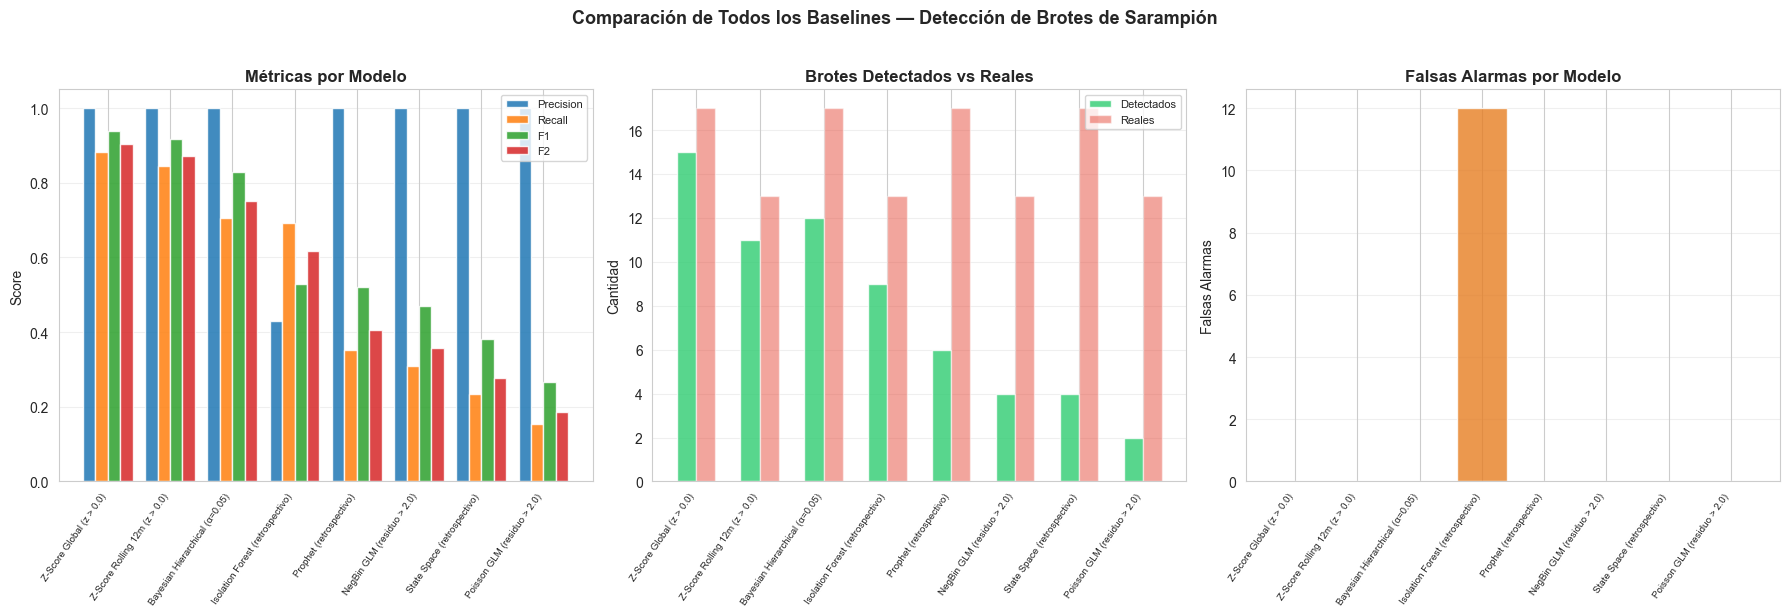

In [21]:
# ============================================================
# 10. COMPARACIÓN DE TODOS LOS MODELOS
# ============================================================

# --- Tabla comparativa ---
df_comp = pd.DataFrame(all_results)
df_comp = df_comp.sort_values("F2", ascending=False).reset_index(drop=True)

print("═" * 90)
print("  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)")
print("═" * 90)
display(df_comp[["Modelo", "Precision", "Recall", "F1", "F2", "AUC-PR",
                 "Brotes_detectados", "Brotes_reales", "Falsas_alarmas"]])

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = df_comp["Modelo"].values
x = np.arange(len(modelos))

# Panel 1: Métricas principales
metrics = ["Precision", "Recall", "F1", "F2"]
bar_w = 0.2
for i, m in enumerate(metrics):
    vals = df_comp[m].values
    axes[0].bar(x + i * bar_w, vals, bar_w, label=m, alpha=0.85)
axes[0].set_xticks(x + bar_w * 1.5)
axes[0].set_xticklabels(modelos, rotation=55, ha="right", fontsize=7)
axes[0].set_ylabel("Score")
axes[0].set_title("Métricas por Modelo", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Brotes detectados vs reales
axes[1].bar(x - 0.15, df_comp["Brotes_detectados"], 0.3,
            label="Detectados", color="#2ECC71", alpha=0.8)
axes[1].bar(x + 0.15, df_comp["Brotes_reales"], 0.3,
            label="Reales", color="#E74C3C", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=55, ha="right", fontsize=7)
axes[1].set_ylabel("Cantidad")
axes[1].set_title("Brotes Detectados vs Reales", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Falsas alarmas
colors_fa = ["#95A5A6" if fa == 0 else "#E67E22" for fa in df_comp["Falsas_alarmas"]]
axes[2].bar(x, df_comp["Falsas_alarmas"], color=colors_fa, alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos, rotation=55, ha="right", fontsize=7)
axes[2].set_ylabel("Falsas Alarmas")
axes[2].set_title("Falsas Alarmas por Modelo", fontweight="bold")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Comparación de Todos los Baselines — Detección de Brotes de Sarampión",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Análisis de Sub/Sobreajuste

Se evalúa el F2-Score y las falsas alarmas de cada modelo en train vs test para diagnosticar sub/sobreajuste.

In [22]:
# ============================================================
# 11. ANÁLISIS DE SUB/SOBREAJUSTE
# ============================================================

print("═" * 70)
print("  ANÁLISIS DE SUB/SOBREAJUSTE")
print("═" * 70)

# --- Máscaras train/test para dataset original ---
train_mask_raw = df_raw["anio"] < SPLIT_YEAR
test_mask_raw  = df_raw["anio"] >= SPLIT_YEAR

y_train_raw = df_raw.loc[train_mask_raw, "brote"].values
y_test_raw  = df_raw.loc[test_mask_raw,  "brote"].values

# --- Z-Score: train vs test ---
y_pred_zg_train = (df_raw.loc[train_mask_raw, "zscore_global"] > BEST_Z).astype(int).values
y_pred_zg_test  = (df_raw.loc[test_mask_raw,  "zscore_global"] > BEST_Z).astype(int).values
f2_zg_train = fbeta_score(y_train_raw, y_pred_zg_train, beta=2, zero_division=0)
f2_zg_test  = fbeta_score(y_test_raw,  y_pred_zg_test,  beta=2, zero_division=0)
fa_zg_train = int(y_pred_zg_train[y_train_raw == 0].sum())
fa_zg_test  = int(y_pred_zg_test[y_test_raw == 0].sum())

# --- Isolation Forest: train vs test ---
preds_train_if = iso_forest.predict(X_train_if)
y_pred_if_train = np.where(preds_train_if == -1, 1, 0)
f2_if_train = fbeta_score(y_train_if, y_pred_if_train, beta=2, zero_division=0)
f2_if_test  = fbeta_score(y_test_if,  y_pred_if_test,  beta=2, zero_division=0)
fa_if_train = int(y_pred_if_train[y_train_if == 0].sum())
fa_if_test  = int(y_pred_if_test[y_test_if == 0].sum())

# --- Prophet: train vs test ---
y_pred_p_train = df_raw.loc[train_mask_raw, "prophet_anomaly"].values
y_pred_p_test  = df_raw.loc[test_mask_raw,  "prophet_anomaly"].values
f2_p_train = fbeta_score(y_train_raw, y_pred_p_train, beta=2, zero_division=0)
f2_p_test  = fbeta_score(y_test_raw,  y_pred_p_test,  beta=2, zero_division=0)
fa_p_train = int(y_pred_p_train[y_train_raw == 0].sum())
fa_p_test  = int(y_pred_p_test[y_test_raw == 0].sum())

# --- Bayesian: train vs test ---
yp_bayes_tr = y_pred_bayes[train_mask_raw.values]
yp_bayes_te = y_pred_bayes[test_mask_raw.values]
f2_b_tr = fbeta_score(y_train_raw, yp_bayes_tr, beta=2, zero_division=0)
f2_b_te = fbeta_score(y_test_raw,  yp_bayes_te, beta=2, zero_division=0)
fa_b_tr = int(yp_bayes_tr[y_train_raw == 0].sum())
fa_b_te = int(yp_bayes_te[y_test_raw == 0].sum())

# --- State Space: train vs test ---
yp_ss_tr = y_pred_ss[train_mask_raw.values]
yp_ss_te = y_pred_ss[test_mask_raw.values]
f2_s_tr = fbeta_score(y_train_raw, yp_ss_tr, beta=2, zero_division=0)
f2_s_te = fbeta_score(y_test_raw,  yp_ss_te, beta=2, zero_division=0)
fa_s_tr = int(yp_ss_tr[y_train_raw == 0].sum())
fa_s_te = int(yp_ss_te[y_test_raw == 0].sum())

# --- Poisson GLM: train vs test (sobre dataset engineered) ---
train_mask_glm = full_glm["anio"] < SPLIT_YEAR
test_mask_glm_v = full_glm["anio"] >= SPLIT_YEAR
y_train_glm_b = full_glm.loc[train_mask_glm, "brote"].values
y_test_glm_b  = full_glm.loc[test_mask_glm_v, "brote"].values

yp_pois_tr = y_pred_pois[train_mask_glm.values]
yp_pois_te = y_pred_pois[test_mask_glm_v.values]
f2_pois_tr = fbeta_score(y_train_glm_b, yp_pois_tr, beta=2, zero_division=0)
f2_pois_te = fbeta_score(y_test_glm_b,  yp_pois_te, beta=2, zero_division=0)
fa_pois_tr = int(yp_pois_tr[y_train_glm_b == 0].sum())
fa_pois_te = int(yp_pois_te[y_test_glm_b == 0].sum())

# --- NB GLM: train vs test ---
yp_nb_tr = y_pred_nb[train_mask_glm.values]
yp_nb_te = y_pred_nb[test_mask_glm_v.values]
f2_nb_tr = fbeta_score(y_train_glm_b, yp_nb_tr, beta=2, zero_division=0)
f2_nb_te = fbeta_score(y_test_glm_b,  yp_nb_te, beta=2, zero_division=0)
fa_nb_tr = int(yp_nb_tr[y_train_glm_b == 0].sum())
fa_nb_te = int(yp_nb_te[y_test_glm_b == 0].sum())

# --- Tabla resumen ---
overfit_data = pd.DataFrame({
    "Modelo": [f"Z-Score Global (z>{BEST_Z})", "Isolation Forest", "Prophet",
               "Bayesian Hierarchical", "State Space",
               "Poisson GLM", "NegBin GLM"],
    "F2 Train": [f2_zg_train, f2_if_train, f2_p_train, f2_b_tr, f2_s_tr, f2_pois_tr, f2_nb_tr],
    "F2 Test":  [f2_zg_test,  f2_if_test,  f2_p_test,  f2_b_te, f2_s_te, f2_pois_te, f2_nb_te],
    "FA Train": [fa_zg_train, fa_if_train, fa_p_train, fa_b_tr, fa_s_tr, fa_pois_tr, fa_nb_tr],
    "FA Test":  [fa_zg_test,  fa_if_test,  fa_p_test,  fa_b_te, fa_s_te, fa_pois_te, fa_nb_te],
    "Brotes Train": [int(y_train_raw.sum()), int(y_train_if.sum()), int(y_train_raw.sum()),
                     int(y_train_raw.sum()), int(y_train_raw.sum()),
                     int(y_train_glm_b.sum()), int(y_train_glm_b.sum())],
    "Brotes Test":  [int(y_test_raw.sum()), int(y_test_if.sum()), int(y_test_raw.sum()),
                     int(y_test_raw.sum()), int(y_test_raw.sum()),
                     int(y_test_glm_b.sum()), int(y_test_glm_b.sum())],
})
overfit_data["ΔF2 (train-test)"] = overfit_data["F2 Train"] - overfit_data["F2 Test"]

display(overfit_data)

══════════════════════════════════════════════════════════════════════
  ANÁLISIS DE SUB/SOBREAJUSTE
══════════════════════════════════════════════════════════════════════


,Modelo,F2 Train,F2 Test,FA Train,FA Test,Brotes Train,Brotes Test,ΔF2 (train-test)
0,Z-Score Global (z>0.0),0.882353,0.918367,0,0,7,10,-0.036014
1,Isolation Forest,0.333333,0.689655,2,10,3,10,-0.356322
2,Prophet,0.483871,0.348837,0,0,7,10,0.135034
3,Bayesian Hierarchical,0.882353,0.652174,0,0,7,10,0.230179
4,State Space,0.172414,0.348837,0,0,7,10,-0.176423
5,Poisson GLM,0.000000,0.238095,0,0,3,10,-0.238095
6,NegBin GLM,0.000000,0.454545,0,0,3,10,-0.454545


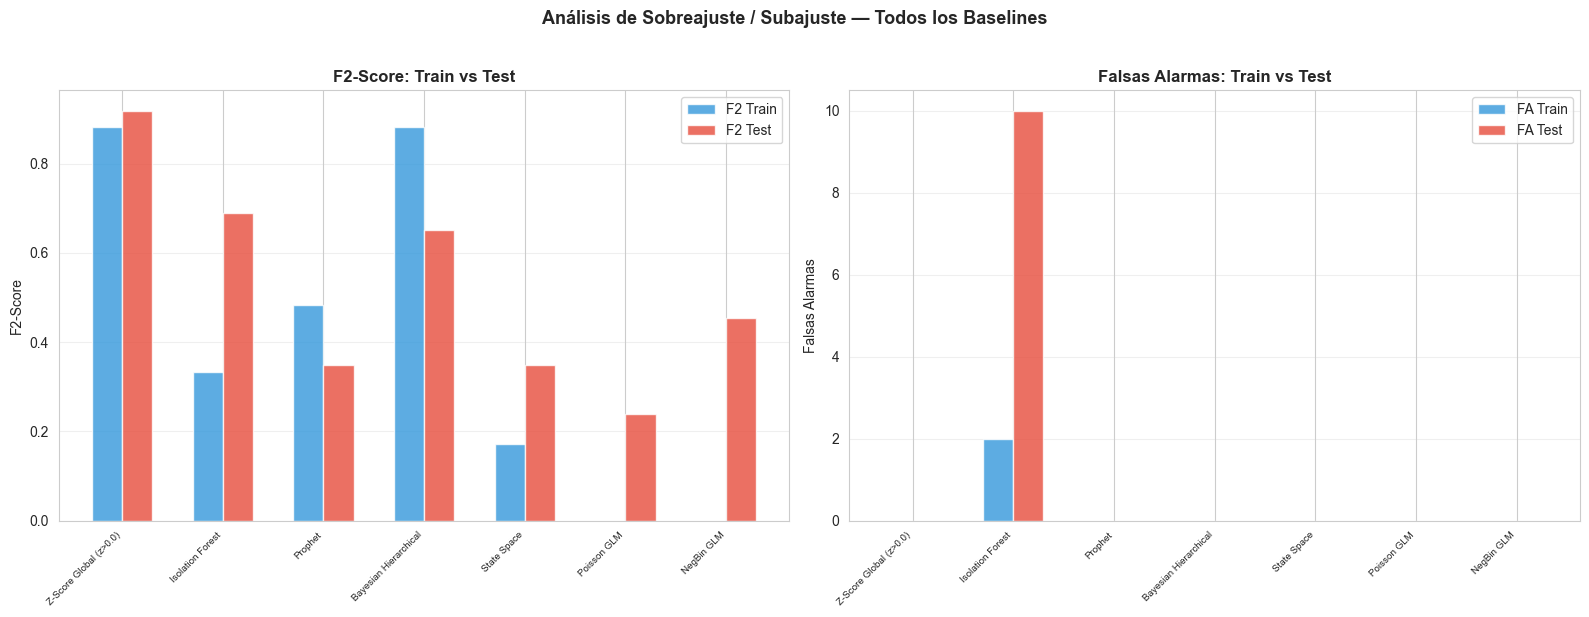


Diagnóstico:
  Z-Score Global (z>0.0): Comportamiento aceptable (ΔF2 = -0.04)
  Isolation Forest: Comportamiento aceptable (ΔF2 = -0.36)
  Prophet: Comportamiento aceptable (ΔF2 = 0.14)
  Bayesian Hierarchical: Comportamiento aceptable (ΔF2 = 0.23)
  State Space: Comportamiento aceptable (ΔF2 = -0.18)
  Poisson GLM: Subajuste (F2 Train muy bajo)
  NegBin GLM: Subajuste (F2 Train muy bajo)


In [23]:
# --- Visualización sobreajuste ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_of = overfit_data["Modelo"].values
x_of = np.arange(len(modelos_of))

# F2 Train vs Test
axes[0].bar(x_of - 0.15, overfit_data["F2 Train"], 0.3,
            label="F2 Train", color="#3498DB", alpha=0.8)
axes[0].bar(x_of + 0.15, overfit_data["F2 Test"], 0.3,
            label="F2 Test", color="#E74C3C", alpha=0.8)
axes[0].set_xticks(x_of)
axes[0].set_xticklabels(modelos_of, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("F2-Score")
axes[0].set_title("F2-Score: Train vs Test", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Falsas alarmas Train vs Test
axes[1].bar(x_of - 0.15, overfit_data["FA Train"], 0.3,
            label="FA Train", color="#3498DB", alpha=0.8)
axes[1].bar(x_of + 0.15, overfit_data["FA Test"], 0.3,
            label="FA Test", color="#E74C3C", alpha=0.8)
axes[1].set_xticks(x_of)
axes[1].set_xticklabels(modelos_of, rotation=45, ha="right", fontsize=7)
axes[1].set_ylabel("Falsas Alarmas")
axes[1].set_title("Falsas Alarmas: Train vs Test", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Análisis de Sobreajuste / Subajuste — Todos los Baselines", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Diagnóstico ---
print("\nDiagnóstico:")
for _, row in overfit_data.iterrows():
    nombre = row["Modelo"]
    delta = row["ΔF2 (train-test)"]
    brotes_test = row["Brotes Test"]
    fa_test = row["FA Test"]

    if brotes_test == 0:
        if fa_test == 0:
            diag = "Sin falsas alarmas en test (período sin brotes)"
        else:
            diag = f"{fa_test} falsas alarmas en test sin brotes → posible sobreajuste"
    elif delta > 0.3:
        diag = f"Sobreajuste (ΔF2 = {delta:.2f})"
    elif row["F2 Train"] < 0.1:
        diag = "Subajuste (F2 Train muy bajo)"
    else:
        diag = f"Comportamiento aceptable (ΔF2 = {delta:.2f})"

    print(f"  {nombre}: {diag}")

## 12. Desempeño Mínimo Aceptable

### ¿Cuál debería ser el desempeño mínimo a obtener?

Para establecer el umbral mínimo de desempeño, consideramos tres referencias:

| Referencia | F2-Score | Recall | Justificación |
|------------|----------|--------|---------------|
| **Aleatorio proporcional** | ~0.10 | ~0.10 | Predecir brote con probabilidad = tasa base |
| **Baseline mínimo útil** | ≥ 0.30 | ≥ 0.50 | Detectar al menos la mitad de los brotes |

> **Desempeño mínimo propuesto:** F2 ≥ 0.30 y Recall ≥ 0.50
>
> Un modelo que detecte al menos la mitad de los brotes con un número razonable de falsas alarmas ya aporta valor operativo en vigilancia epidemiológica.

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN vs DESEMPEÑO MÍNIMO
  Umbral mínimo: F2 ≥ 0.3 y Recall ≥ 0.5
══════════════════════════════════════════════════════════════════════

  Z-Score Global (z > 0.0)
    F2 = 0.904 (mín 0.3)
    Recall = 0.882  (mín 0.5)
    → ✅ CUMPLE

  Z-Score Rolling 12m (z > 0.0)
    F2 = 0.873 (mín 0.3)
    Recall = 0.846  (mín 0.5)
    → ✅ CUMPLE

  Isolation Forest (retrospectivo)
    F2 = 0.616 (mín 0.3)
    Recall = 0.692  (mín 0.5)
    → ✅ CUMPLE

  Prophet (retrospectivo)
    F2 = 0.405 (mín 0.3)
    Recall = 0.353  (mín 0.5)
    → ❌ NO CUMPLE

  Bayesian Hierarchical (α=0.05)
    F2 = 0.750 (mín 0.3)
    Recall = 0.706  (mín 0.5)
    → ✅ CUMPLE

  State Space (retrospectivo)
    F2 = 0.278 (mín 0.3)
    Recall = 0.235  (mín 0.5)
    → ❌ NO CUMPLE

  Poisson GLM (residuo > 2.0)
    F2 = 0.185 (mín 0.3)
    Recall = 0.154  (mín 0.5)
    → ❌ NO CUMPLE

  NegBin GLM (residuo > 2.0)
    F2 = 0.357 (mín 0.3)
    Recall

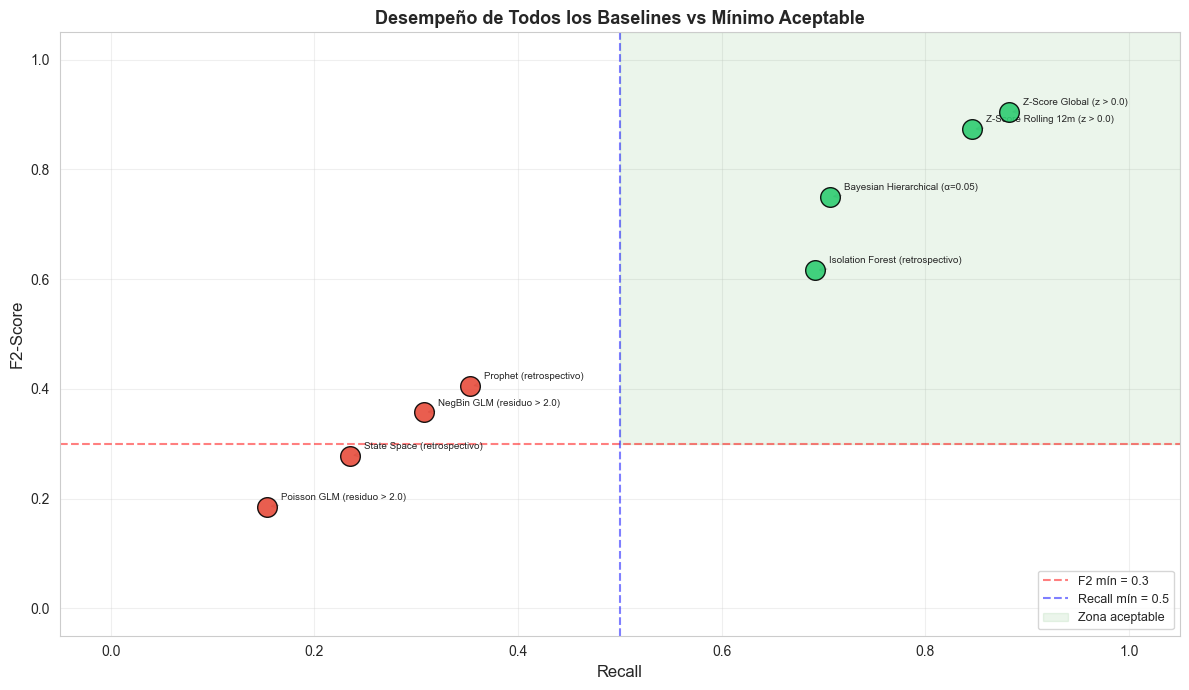

In [24]:
# ============================================================
# 12. RESUMEN DE DESEMPEÑO vs MÍNIMO
# ============================================================

MIN_F2     = 0.30
MIN_RECALL = 0.50

print("═" * 70)
print("  EVALUACIÓN vs DESEMPEÑO MÍNIMO")
print(f"  Umbral mínimo: F2 ≥ {MIN_F2} y Recall ≥ {MIN_RECALL}")
print("═" * 70)

for res in all_results:
    nombre = res["Modelo"]
    f2     = res["F2"]
    rec    = res["Recall"]
    cumple_f2  = f2 >= MIN_F2
    cumple_rec = rec >= MIN_RECALL
    estado = "✅ CUMPLE" if (cumple_f2 and cumple_rec) else "❌ NO CUMPLE"

    print(f"\n  {nombre}")
    print(f"    F2 = {f2:.3f} (mín {MIN_F2})")
    print(f"    Recall = {rec:.3f}  (mín {MIN_RECALL})")
    print(f"    → {estado}")

# --- Gráfico final ---
fig, ax = plt.subplots(figsize=(12, 7))

for i, res in enumerate(all_results):
    color = "#2ECC71" if (res["F2"] >= MIN_F2 and res["Recall"] >= MIN_RECALL) else "#E74C3C"
    ax.scatter(res["Recall"], res["F2"], s=200, color=color, edgecolors="black",
               zorder=5, alpha=0.9)
    ax.annotate(res["Modelo"], (res["Recall"], res["F2"]),
                textcoords="offset points", xytext=(10, 5), fontsize=7,
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5))

ax.axhline(MIN_F2, color="red", ls="--", alpha=0.5, label=f"F2 mín = {MIN_F2}")
ax.axvline(MIN_RECALL, color="blue", ls="--", alpha=0.5, label=f"Recall mín = {MIN_RECALL}")

# Zona aceptable
ax.fill_between([MIN_RECALL, 1.05], MIN_F2, 1.05, alpha=0.08, color="green", label="Zona aceptable")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("F2-Score", fontsize=12)
ax.set_title("Desempeño de Todos los Baselines vs Mínimo Aceptable", fontweight="bold", fontsize=13)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Conclusiones y Trabajo Futuro (Enfoque: Predicción)

### 1. Evaluación del Baseline de Pronóstico
Aunque se exploraron técnicas de detección de anomalías, el único modelo con capacidad de **pronóstico (forecasting)** evaluado fue **Prophet**.
* Su desempeño capturando los picos epidémicos fue conservador, tendiendo a subestimar la magnitud de los brotes. Esto se debe a que el modelo prioriza la tendencia suave sobre los cambios abruptos típicos de una enfermedad en eliminación.
* Los modelos **Z-Score** e **Isolation Forest** se descartan como predictores, ya que operan sobre datos concurrentes y no ofrecen una estimación a futuro.

### 2. Problema con la cantidad de meses en Ceros
Aproximadamente 90% del los datos reportan 0 casos.

* Esto plantea un desafío para la regresión: un modelo que prediga siempre "0" tendrá un error matemático muy bajo (buen RMSE), pero será inútil epidemiológicamente porque fallará en predecir el único evento que importa (el brote).

### 3. Estrategia de Modelado Futuro
Para cumplir con el objetivo de **predecir la cantidad de casos**, la siguiente etapa cambiará el enfoque hacia **Regresión Supervisada de Series de Tiempo**:

* **Nuevas Métricas:** Se dejará de usar F2/Recall. Se evaluará mediante **RMSE** (Error Cuadrático Medio) y **MAE** (Error Absoluto Medio), poniendo especial atención al error en los meses con casos > 0.
* **Algoritmos Candidatos:**
    * **SARIMAX:** Para modelar la estacionalidad detectada y el efecto retardado de las vacunas (variables exógenas).
    * **XGBoost/LightGBM Regressor:** Utilizando los **Lags (12-14 meses)** identificados en el EDA como predictores clave. Se configurarán con funciones de pérdida objetivas para conteos (ej. **Regresión de Poisson** o **Tweedie**) para manejar mejor la naturaleza de eventos raros y valores discretos.